# Imports and setup

In [41]:
### Import packages
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, silhouette_score, log_loss
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier


In [ ]:
### Read in data and display
games_df = pd.read_csv('games.csv')
player_play_df = pd.read_csv('player_play.csv')
players_df = pd.read_csv('players.csv')
plays_df = pd.read_csv('plays.csv')

print('Games DataFrame')
display(games_df.head(10))
print(games_df.columns)
print()
print('================================================================')
print('================================================================')
print()

print('Player Play DataFrame')
display(player_play_df.head(10))
print(player_play_df.columns)
print()
print('================================================================')
print('================================================================')
print()

print('Players DataFrame')
display(players_df.head(10))
print(players_df.columns)
print()
print('================================================================')
print('================================================================')
print()

print('Plays DataFrame')
display(plays_df.head(10))
print(plays_df.columns)

Games DataFrame


,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
0,2022090800,2022,1,9/8/2022,20:20:00,LA,BUF,10,31
1,2022091100,2022,1,9/11/2022,13:00:00,ATL,NO,26,27
2,2022091101,2022,1,9/11/2022,13:00:00,CAR,CLE,24,26
3,2022091102,2022,1,9/11/2022,13:00:00,CHI,SF,19,10
4,2022091103,2022,1,9/11/2022,13:00:00,CIN,PIT,20,23
5,2022091104,2022,1,9/11/2022,13:00:00,DET,PHI,35,38
6,2022091105,2022,1,9/11/2022,13:00:00,HOU,IND,20,20
7,2022091106,2022,1,9/11/2022,13:00:00,MIA,NE,20,7
8,2022091107,2022,1,9/11/2022,13:00:00,NYJ,BAL,9,24
9,2022091109,2022,1,9/11/2022,13:00:00,WAS,JAX,28,22


Index(['gameId', 'season', 'week', 'gameDate', 'gameTimeEastern',
       'homeTeamAbbr', 'visitorTeamAbbr', 'homeFinalScore',
       'visitorFinalScore'],
      dtype='object')


Player Play DataFrame


,gameId,playId,nflId,teamAbbr,hadRushAttempt,rushingYards,hadDropback,passingYards,sackYardsAsOffense,hadPassReception,...,wasRunningRoute,routeRan,blockedPlayerNFLId1,blockedPlayerNFLId2,blockedPlayerNFLId3,pressureAllowedAsBlocker,timeToPressureAllowedAsBlocker,pff_defensiveCoverageAssignment,pff_primaryDefensiveCoverageMatchupNflId,pff_secondaryDefensiveCoverageMatchupNflId
0,2022090800,56,35472,BUF,0,0,0,0,0,0,...,NaN,NaN,47917.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,2022090800,56,42392,BUF,0,0,0,0,0,0,...,NaN,NaN,47917.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,2022090800,56,42489,BUF,0,0,0,0,0,1,...,1.0,IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022090800,56,44875,BUF,0,0,0,0,0,0,...,NaN,NaN,43335.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
4,2022090800,56,44985,BUF,0,0,0,0,0,0,...,1.0,OUT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2022090800,56,46076,BUF,0,0,1,6,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2022090800,56,47857,BUF,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2022090800,56,47879,BUF,0,0,0,0,0,0,...,1.0,IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2022090800,56,48512,BUF,0,0,0,0,0,0,...,NaN,NaN,41239.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
9,2022090800,56,52536,BUF,0,0,0,0,0,0,...,1.0,GO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Index(['gameId', 'playId', 'nflId', 'teamAbbr', 'hadRushAttempt',
       'rushingYards', 'hadDropback', 'passingYards', 'sackYardsAsOffense',
       'hadPassReception', 'receivingYards', 'wasTargettedReceiver',
       'yardageGainedAfterTheCatch', 'fumbles', 'fumbleLost',
       'fumbleOutOfBounds', 'assistedTackle', 'forcedFumbleAsDefense',
       'halfSackYardsAsDefense', 'passDefensed', 'quarterbackHit',
       'sackYardsAsDefense', 'safetyAsDefense', 'soloTackle', 'tackleAssist',
       'tackleForALoss', 'tackleForALossYardage', 'hadInterception',
       'interceptionYards', 'fumbleRecoveries', 'fumbleRecoveryYards',
       'penaltyYards', 'penaltyNames', 'wasInitialPassRusher',
       'causedPressure', 'timeToPressureAsPassRusher',
       'getOffTimeAsPassRusher', 'inMotionAtBallSnap', 'shiftSinceLineset',
       'motionSinceLineset', 'wasRunningRoute', 'routeRan',
       'blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3',
       'pressureAllowedAsBlocker', 'timeT

,nflId,height,weight,birthDate,collegeName,position,displayName
0,25511,6-4,225,1977-08-03,Michigan,QB,Tom Brady
1,29550,6-4,328,1982-01-22,Arkansas,T,Jason Peters
2,29851,6-2,225,1983-12-02,California,QB,Aaron Rodgers
3,30842,6-6,267,1984-05-19,UCLA,TE,Marcedes Lewis
4,33084,6-4,217,1985-05-17,Boston College,QB,Matt Ryan
5,33099,6-6,245,1985-01-16,Delaware,QB,Joe Flacco
6,33107,6-4,315,1985-08-30,Virginia Tech,T,Duane Brown
7,33130,5-10,175,1986-12-01,California,WR,DeSean Jackson
8,33131,6-8,300,1986-09-01,Miami,DE,Calais Campbell
9,33138,6-3,222,1985-07-02,Michigan,QB,Chad Henne


Index(['nflId', 'height', 'weight', 'birthDate', 'collegeName', 'position',
       'displayName'],
      dtype='object')


Plays DataFrame


,gameId,playId,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,...,yardsGained,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPointsAdded,isDropback,pff_runConceptPrimary,pff_runConceptSecondary,pff_runPassOption,pff_passCoverage,pff_manZone
0,2022102302,2655,(1:54) (Shotgun) J.Burrow pass short middle to...,3,1,10,CIN,ATL,CIN,21,...,9,0.004634,-0.004634,0.702717,True,NaN,NaN,0,Cover-3,Zone
1,2022091809,3698,(2:13) (Shotgun) J.Burrow pass short right to ...,4,1,10,CIN,DAL,CIN,8,...,4,0.002847,-0.002847,-0.240509,True,NaN,NaN,0,Quarters,Zone
2,2022103004,3146,(2:00) (Shotgun) D.Mills pass short right to D...,4,3,12,HOU,TEN,HOU,20,...,6,0.000205,-0.000205,-0.218480,True,NaN,NaN,0,Quarters,Zone
3,2022110610,348,(9:28) (Shotgun) P.Mahomes pass short left to ...,1,2,10,KC,TEN,TEN,23,...,4,-0.001308,0.001308,-0.427749,True,NaN,NaN,0,Quarters,Zone
4,2022102700,2799,(2:16) (Shotgun) L.Jackson up the middle to TB...,3,2,8,BAL,TB,TB,27,...,-1,0.027141,-0.027141,-0.638912,False,MAN,READ OPTION,0,Cover-1,Man
5,2022100205,2314,(14:15) Ja.Williams up the middle to DET 32 fo...,3,2,6,DET,SEA,DET,29,...,3,-0.024210,0.024210,-0.442517,False,MAN,NaN,0,Cover 6-Left,Zone
6,2022110605,3861,(:29) (Shotgun) J.Wilkins up the middle to IND...,4,1,10,IND,NE,IND,40,...,5,0.002189,-0.002189,-0.991169,False,INSIDE ZONE,NaN,0,Cover-2,Zone
7,2022100203,3994,(:35) K.Murray kneels to CAR 29 for -1 yards.,4,3,12,ARI,CAR,CAR,28,...,-1,-0.005253,0.005253,0.000000,False,UNDEFINED,NaN,0,NaN,NaN
8,2022091104,3662,(12:51) (Shotgun) J.Hurts pass incomplete shor...,4,3,12,PHI,DET,PHI,35,...,0,0.012361,-0.012361,-1.161621,True,NaN,NaN,0,Cover-0,Man
9,2022100204,1422,(5:22) (Shotgun) C.Rush pass short left to M.G...,2,3,8,DAL,WAS,DAL,35,...,15,0.058490,-0.058490,2.194760,True,NaN,NaN,0,Quarters,Zone


Index(['gameId', 'playId', 'playDescription', 'quarter', 'down', 'yardsToGo',
       'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber',
       'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore',
       'playNullifiedByPenalty', 'absoluteYardlineNumber',
       'preSnapHomeTeamWinProbability', 'preSnapVisitorTeamWinProbability',
       'expectedPoints', 'offenseFormation', 'receiverAlignment',
       'playClockAtSnap', 'passResult', 'passLength', 'targetX', 'targetY',
       'playAction', 'dropbackType', 'dropbackDistance', 'passLocationType',
       'timeToThrow', 'timeInTackleBox', 'timeToSack', 'passTippedAtLine',
       'unblockedPressure', 'qbSpike', 'qbKneel', 'qbSneak',
       'rushLocationType', 'penaltyYards', 'prePenaltyYardsGained',
       'yardsGained', 'homeTeamWinProbabilityAdded',
       'visitorTeamWinProbilityAdded', 'expectedPointsAdded', 'isDropback',
       'pff_runConceptPrimary', 'pff_runConceptSecondary', 'pff_runPassOption',
       'pff_pass

# Overview of Analysis

American Football is the most popular sport in the USA. Millions of children and youth around the country participate in organized football each year. College football is hugely popular both to play and watch, with the NCAA reporting an annual revenue of 1.3 billion dollars for the 2022-2023 football season. Professional football, the NFL, is also extremely popular, with reported annual revenue for 2024 being over 23 billion dollars. Fans, players, and teams all want to win, and by analyzing the behavior of offenses in the NFL, we can help defense prepare to stop their opponents and increase their chance of winning.

We analyze team behavior and try to predict whether an offense will pass or run the ball in what we have determined to be "fringe field goal range". This part of the field is 40-55 yards away from the defensive team's endzone. We ask the question: are some teams more predictable in this part of the field than others? What makes these teams more predictable than others? After an extensive analysis, we provide a proven framework for answering these questions in this repo. Given more weeks of data from the NFL, we believe this framework would be even more effective at answering these two questions.

# Background on football

## Ways to score

**Touchdowns** are scored by the team posessing the ball in their opponents endzone either by running with the ball into the endzone or catching the ball inside of their opponents endzone. A touchdown awards 6 points to the team who scores it and is followed by an extra point attempt where the kicker does a short kick through the field goal posts for another 1 point.

**Field goals** are scored by a kicker kicking the ball through the field goal posts. A field goal awards the team who scores it 3 points.

[Touchdown Examples](https://www.youtube.com/watch?v=PY1MkLWkMzk)

[Field Goal Examples](https://www.youtube.com/watch?v=1pDgSvYNIyY)

## Probability of scoring based on field position

Offenses are always trying to advance the football down the field. They advance the ball in discrete plays. They are constantly trying to (1) score a touchdown or (2) kick a field goal to score. The probability that they score (either through a touchdown or a field goal) on a given play increases as they get closer to their opponent's endzone. The medium area below is what we define as "fringe field goal range".

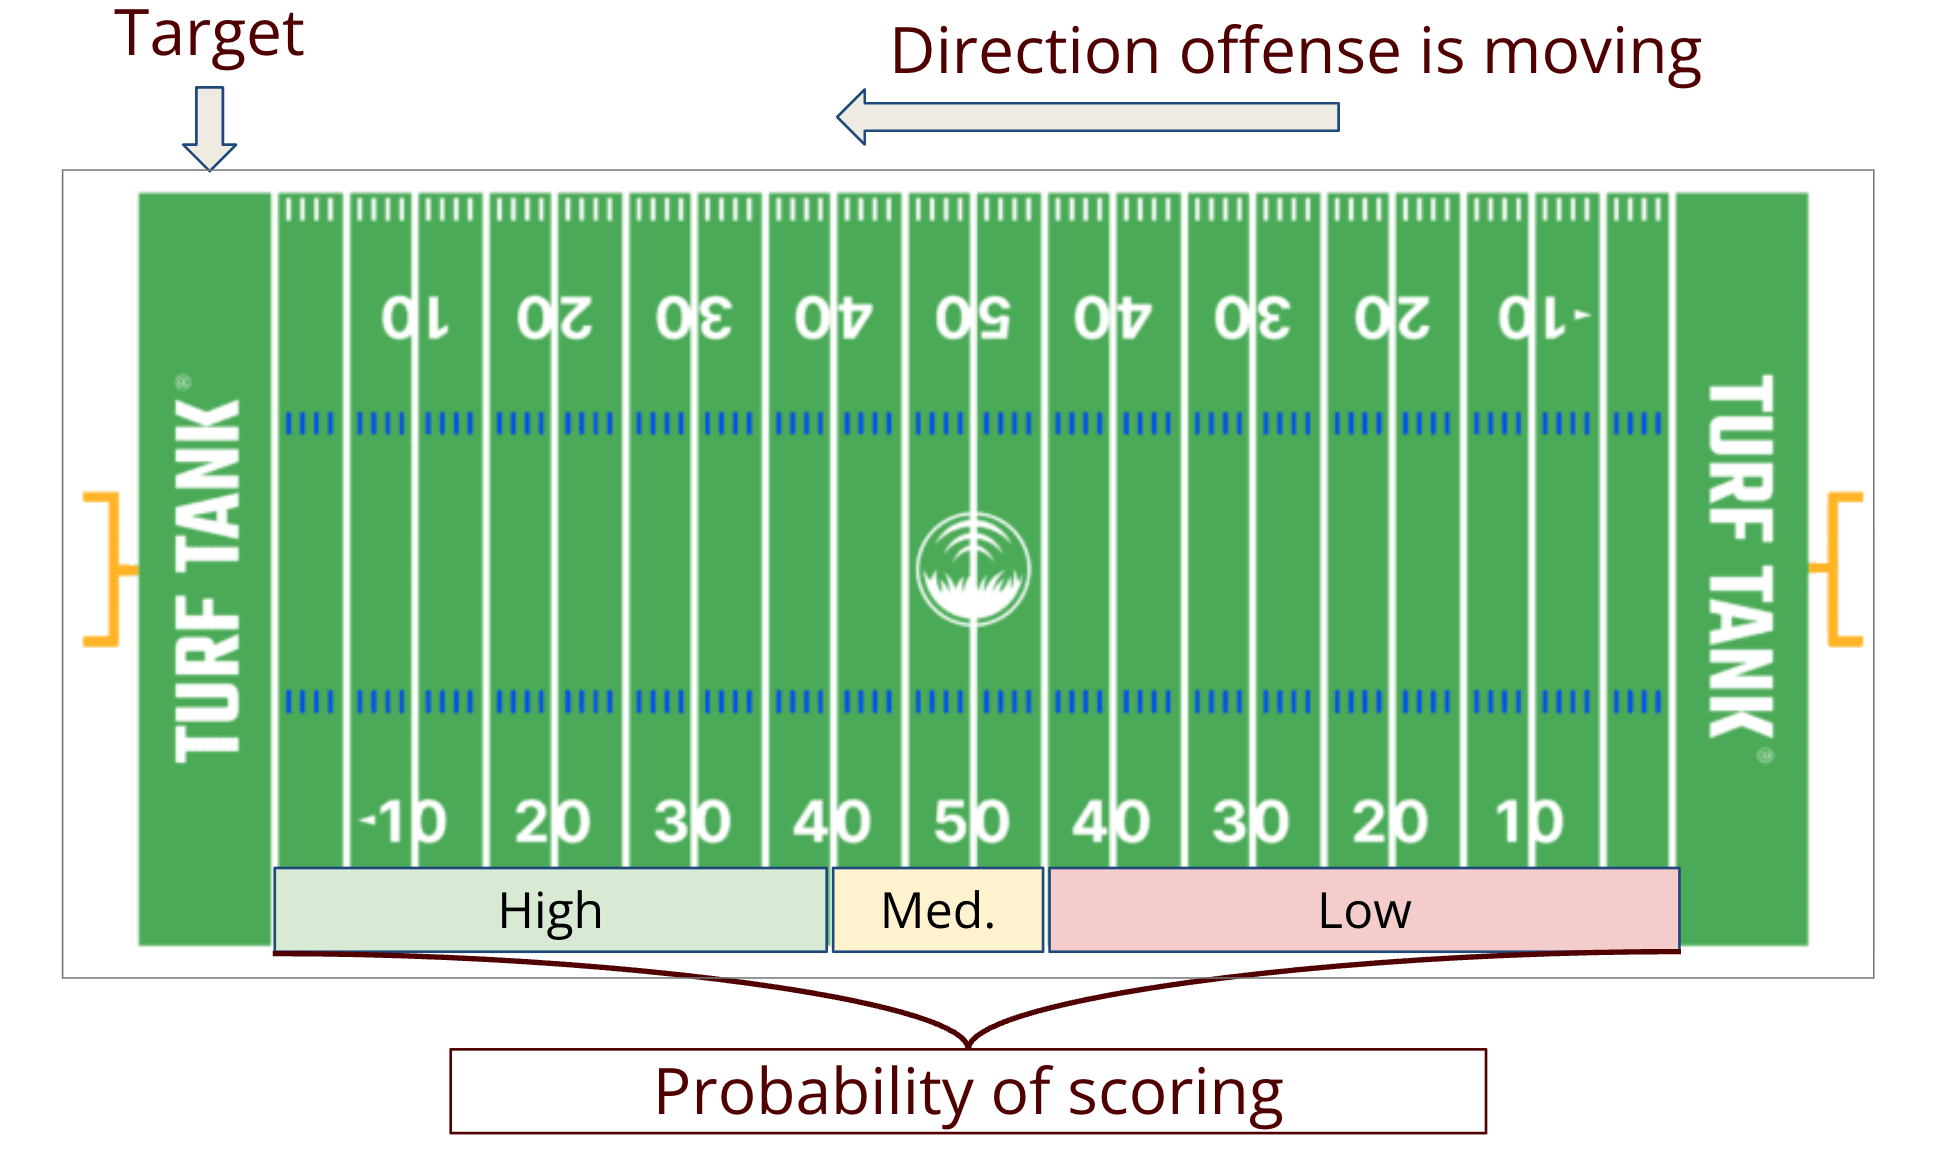

## Why analyze the fringe field goal range?

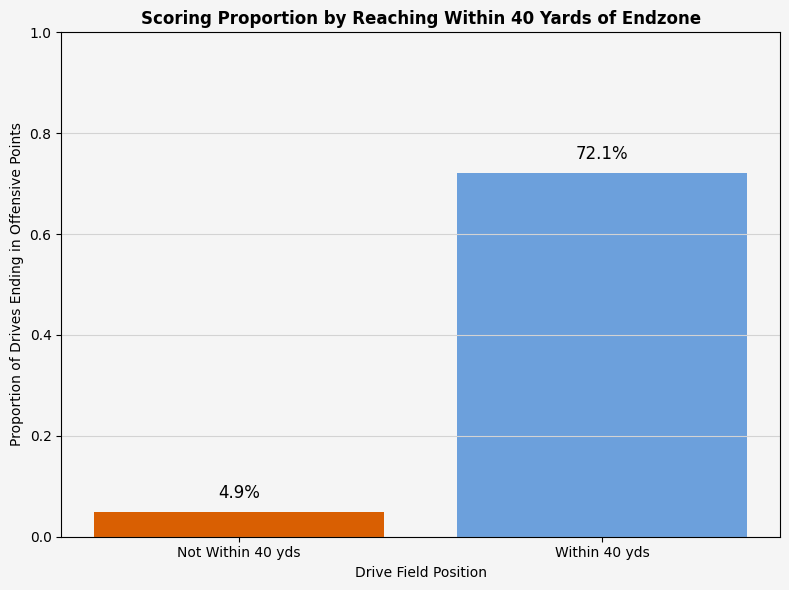

In [ ]:
### Set the yardline threshold for easy modification (represents yards away from opponent's endzone)
yardline_threshold = 40

# Copy plays_df to a new dataframe for processing
working_plays_df = plays_df.copy()

# Sort plays to ensure chronological order for drive grouping
working_plays_df = working_plays_df.sort_values(['gameId', 'playId'])

# Create a unique drive ID by looking at changes in possession or game
working_plays_df['possession_change'] = (working_plays_df['possessionTeam'] != working_plays_df['possessionTeam'].shift(1)) | \
                                (working_plays_df['gameId'] != working_plays_df['gameId'].shift(1))
working_plays_df['drive_id'] = working_plays_df['possession_change'].cumsum()

# Calculate true distance to goal to account for drive direction
working_plays_df['distance_to_goal'] = np.where(
    working_plays_df['yardlineSide'] == working_plays_df['possessionTeam'],
    100 - working_plays_df['yardlineNumber'],
    working_plays_df['yardlineNumber']
)

# Merge home and visitor team info from games_df to know which score belongs to the possession team
if 'homeTeamAbbr' not in working_plays_df.columns:
    working_plays_df = working_plays_df.merge(games_df[['gameId', 'homeTeamAbbr', 'visitorTeamAbbr']], on='gameId', how='left')

# Get the post-play score by looking at the next play's pre-snap score (within the same game)
working_plays_df['postSnapHomeScore'] = working_plays_df.groupby('gameId')['preSnapHomeScore'].shift(-1).fillna(working_plays_df['preSnapHomeScore'])
working_plays_df['postSnapVisitorScore'] = working_plays_df.groupby('gameId')['preSnapVisitorScore'].shift(-1).fillna(working_plays_df['preSnapVisitorScore'])

# Calculate the score change on each play
working_plays_df['homeScoreChange'] = working_plays_df['postSnapHomeScore'] - working_plays_df['preSnapHomeScore']
working_plays_df['visitorScoreChange'] = working_plays_df['postSnapVisitorScore'] - working_plays_df['preSnapVisitorScore']

# Isolate points scored by the possession (offensive) team
working_plays_df['offensivePointsScored'] = 0
home_pos = working_plays_df['possessionTeam'] == working_plays_df['homeTeamAbbr']
vis_pos = working_plays_df['possessionTeam'] == working_plays_df['visitorTeamAbbr']

working_plays_df.loc[home_pos, 'offensivePointsScored'] = working_plays_df.loc[home_pos, 'homeScoreChange']
working_plays_df.loc[vis_pos, 'offensivePointsScored'] = working_plays_df.loc[vis_pos, 'visitorScoreChange']

# Group by drive and aggregate
drives_df = working_plays_df.groupby('drive_id').agg(
    # Check if any play in the drive reached or passed the true distance to goal threshold
    crossed_threshold=('distance_to_goal', lambda x: (x <= yardline_threshold).any()),
    # Check if offensive points were scored > 0
    scored=('offensivePointsScored', lambda x: (x > 0).any())
).reset_index()

# Calculate proportions of scoring drives for each group
summary = drives_df.groupby('crossed_threshold')['scored'].mean().reset_index()
summary['crossed_threshold_label'] = summary['crossed_threshold'].map({True: f'Within {yardline_threshold} yds', False: f'Not Within {yardline_threshold} yds'})

# Plotting the proportions
fig, ax = plt.subplots(figsize=(8, 6))

# Set background colors
fig.patch.set_facecolor('#F5F5F5') # Very light gray for the figure background
ax.set_facecolor('#F5F5F5') # Very light gray for the axes background

# Define bar colors: first for 'Not Within', second for 'Within' based on summary DataFrame order
bar_colors = ['#d95f02', '#6CA0DC'] # Original color for 'Not Within', light blue for 'Within 40 yds'

ax.bar(summary['crossed_threshold_label'], summary['scored'], color=bar_colors)

ax.set_xlabel('Drive Field Position')
ax.set_ylabel('Proportion of Drives Ending in Offensive Points')
ax.set_title(f'Scoring Proportion by Reaching Within {yardline_threshold} Yards of Endzone', fontweight='bold') # Bold title
ax.set_ylim(0, 1.0)

# Add horizontal grid lines
ax.grid(axis='y', linestyle='-', color='lightgray')

# Add text annotations on top of bars
for bar in ax.patches:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

As shown above, offenses score 72% of the time when getting within 40 yards of the defense's endzone, where as if they are stopped before the 40 yard line, they only score 5% of the time. Therefore if we can help defenses predict if the offense is going to pass or run the ball for a given play within the key area of the field, then they would be able to effectively prepare against that--greatly limit the number of points that the offense would be able to score.

# Datasets

## Fringe field goal range and unbalanced data

There are 9 weeks of data available in the dataset.



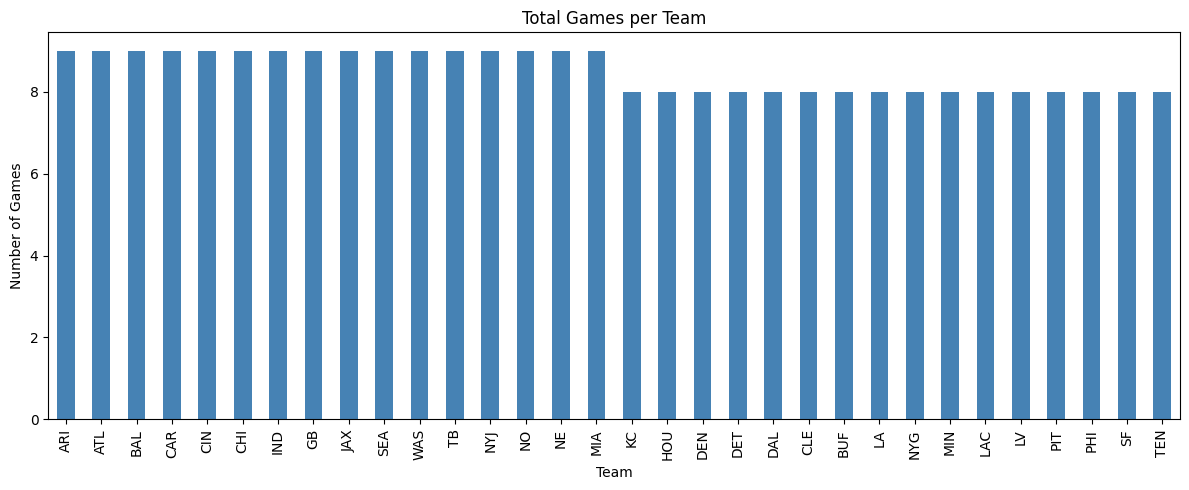

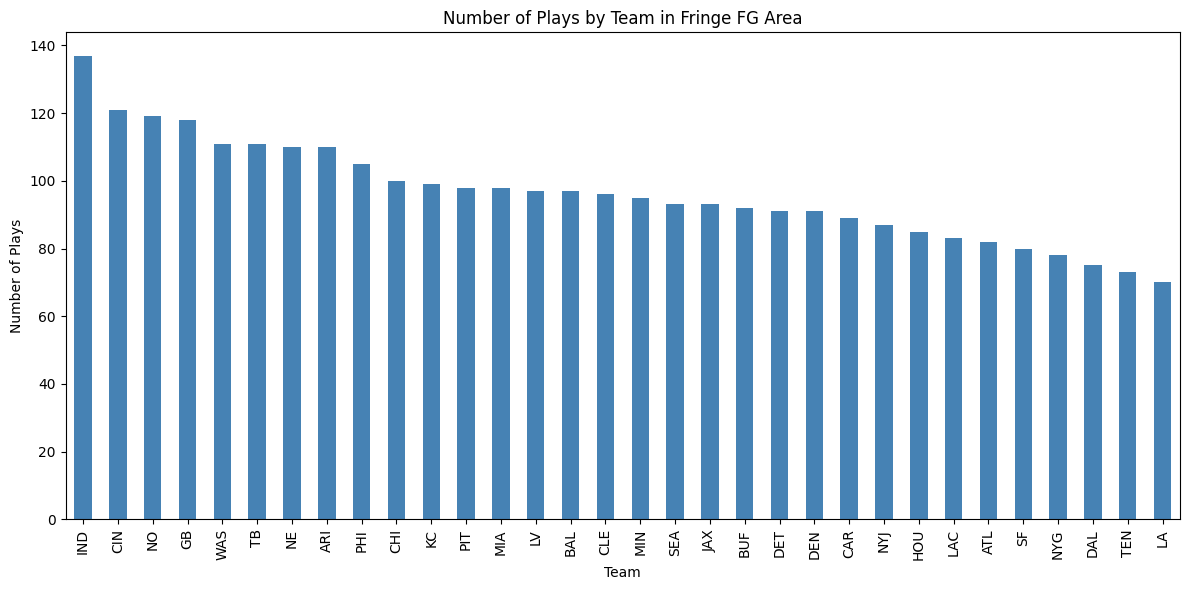

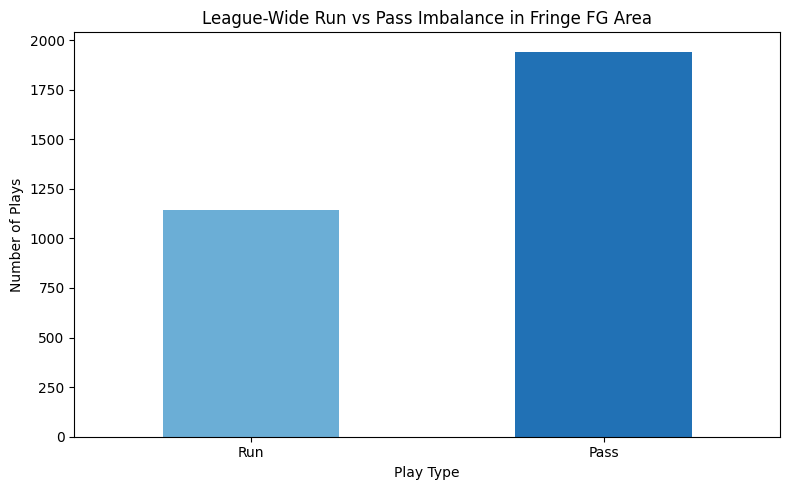

In [39]:
### 1. Print: How many weeks of data there are
num_weeks = games_df['week'].nunique()
print(f"There are {num_weeks} weeks of data available in the dataset.\n")

### 2. Visualization: Games played by each team
home_games = games_df['homeTeamAbbr'].value_counts()
visitor_games = games_df['visitorTeamAbbr'].value_counts()
total_games = home_games.add(visitor_games, fill_value=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
total_games.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Team")
ax.set_ylabel("Number of Games")
ax.set_title("Total Games per Team")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 3. Visualization: Plays by each team in Fringe FG Area
fringe_df = plays_df[plays_df["absoluteYardlineNumber"].between(40, 55)].copy()
fringe_df = fringe_df[fringe_df["down"] != 4]
counts = fringe_df["possessionTeam"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Team")
ax.set_ylabel("Number of Plays")
ax.set_title("Number of Plays by Team in Fringe FG Area")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4. Visualization: Run vs Pass plays by everyone in the league
play_type = fringe_df["passResult"].isna().map({True: "Run", False: "Pass"})
rp_counts = play_type.value_counts().reindex(["Run", "Pass"], fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
rp_counts.plot(kind="bar", ax=ax, color=["#6baed6", "#2171b5"])
ax.set_xlabel("Play Type")
ax.set_ylabel("Number of Plays")
ax.set_title("League-Wide Run vs Pass Imbalance in Fringe FG Area")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


- This data is only 9 weeks worth of games, with some teams having a game each week, and other teams having only 8 games. Because of this, we focus on developing a framework for this analysis rather than being able to make sure claims on the teams from this data.
- This shows the amount of plays that each team had within fringe field goal range during those 9 weeks of games.
- The data is unbalanced, and the training datasets are balanced using undersampling before training the models. The test datasets are not balanced.

# Modeling for all of the league

The goal here is to see if we can get a model that will predict if a team is going to pass or run on a non-4th down play in the "field goal fringe area" of the field. Rather than focusing on a single team, we train and evaluate 3 different models on data from all teams across the league. This will help answer the question "Can we predict if a team will pass or run in the fringe field goal range in general?". If the answer is yes, we can move on to predicting the same for an individual team.

The three models are:
1. DecisionTree with a max_depth=3
    - This is intended as a simple baseline to compare the other two models to, given the small amount of data we are using this actually performs well compared to the other models. However given more data, I believe that this would not be the case.
2. RandomForest
3. XGBoost

The RandomForest and XGBoost hyperparameters are tuned with a Randomized Grid Search. Their effectiveness is evaluated with a 5 fold cross validation with the following metrics:
- Accuracy
- Precision
- Recall
- Macro F1
  - This is used to not favor pass play predictions over run play predictions

## Preprocessing

In [6]:
def get_fringe_df(closest_yards_to_endzone, furthest_yards_to_endzone, df=plays_df):
    fringe_df = df.copy()

    fringe_df = fringe_df[fringe_df["down"]!=4]

    fringe_df[['minutes', 'seconds']] = fringe_df['gameClock'].str.split(':', expand=True)

    fringe_df['minutes'] = pd.to_numeric(fringe_df['minutes'])
    fringe_df['seconds'] = pd.to_numeric(fringe_df['seconds'])

    fringe_df['seconds_remaining_in_quarter'] = fringe_df['minutes'] * 60 + fringe_df['seconds']

    fringe_df['yards_to_endzone'] = np.where(
        fringe_df['yardlineSide'] == fringe_df['possessionTeam'],
        100 - fringe_df['yardlineNumber'],
        fringe_df['yardlineNumber']
    )

    # Filter to only include plays within the fringe field goal range
    fringe_df = fringe_df[(fringe_df['yards_to_endzone']>=closest_yards_to_endzone)&(fringe_df['yards_to_endzone']<=furthest_yards_to_endzone)]

    # Map target variable: Pass = 1, Run = 0
    fringe_df['is_pass'] = fringe_df['passResult'].notna().astype(int)

    # Merge with games_df to get homeTeamAbbr so we know who is on offense
    if 'homeTeamAbbr' not in fringe_df.columns:
        fringe_df = fringe_df.merge(games_df[['gameId', 'homeTeamAbbr']], on='gameId', how='left')

    # Calculate offensive team win probability
    fringe_df['preSnapOffTeamWinProbability'] = np.where(
        fringe_df['possessionTeam'] == fringe_df['homeTeamAbbr'],
        fringe_df['preSnapHomeTeamWinProbability'],
        fringe_df['preSnapVisitorTeamWinProbability']
    )

    fringe_df = fringe_df.loc[:,
        [
          'quarter',
          'down',
          'yardsToGo',
          'possessionTeam',
          'defensiveTeam',
          'yards_to_endzone',
          'seconds_remaining_in_quarter',
          'preSnapOffTeamWinProbability',
          'offenseFormation',
          'receiverAlignment',
          'playClockAtSnap',
          'is_pass'
      ]
    ]

    fringe_df = fringe_df.dropna()

    return fringe_df


def cleaning_fringe_df(df, binary_target):
    """
    Takes in the df, splits it, balances the train data, and outputs ready for preprocessing/model training

    Input: df with only response and explanatory variables you want to use

    Output: X_train_raw, X_test_raw, y_train, y_test ready for preprocessing and model fitting
    """

    # Create Train/Test Split (80/20)
    train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[binary_target]) # random_state=117

    # Balance the training set by undersampling
    pass_plays = train_df[train_df[binary_target] == 1]
    run_plays = train_df[train_df[binary_target] == 0]

    # Check distribution of playtype

    min_samples = min(len(pass_plays), len(run_plays))

    balanced_train_df = pd.concat([
        pass_plays.sample(min_samples, random_state=42),
        run_plays.sample(min_samples, random_state=42)
    ]).sample(frac=1, random_state=117) # Shuffle

    # Separate Features and Target
    X_train_raw = balanced_train_df.drop(columns=[binary_target])
    y_train = balanced_train_df[binary_target]

    X_test_raw = test_df.drop(columns=[binary_target])
    y_test = test_df[binary_target]

    print(f"Original training size: {len(train_df)}")
    print(f"Balanced training size: {len(balanced_train_df)}")
    print(f"Processed feature shape: {X_train_raw.shape}")
    print(f"Test set size: {len(test_df)}")

    return X_train_raw, X_test_raw, y_train, y_test, len(balanced_train_df), len(test_df)


def define_dt_rf_xgb_pipelines(categorical, numeric):
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
            ("num", StandardScaler(), numeric),
        ]
    )

    # 1. Decision Tree Pipeline (Fixed max_depth=3)
    dt_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=3))
    ])

    # 2. Random Forest Pipeline with Randomized Search
    rf_base_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=117))
    ])

    rf_param_dist = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [2, 3, 5, 10, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 4, 8]
    }

    rf_random_search = RandomizedSearchCV(
        rf_base_pipe,
        param_distributions=rf_param_dist,
        n_iter=10,
        cv=3,
        random_state=117,
        n_jobs=-1,
        scoring='f1_macro'
    )

    # 3. XGBoost Pipeline with Randomized Search
    xgb_base_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=117))
    ])

    xgb_param_dist = {
        'classifier__max_depth': [2, 3, 4, 5, 6],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__n_estimators': [100, 200],
        'classifier__subsample': [0.8, 1.0]
    }

    xgb_random_search = RandomizedSearchCV(
        xgb_base_pipe,
        param_distributions=xgb_param_dist,
        n_iter=10,
        cv=3,
        random_state=117,
        n_jobs=-1,
        scoring='f1_macro'
    )

    return dt_pipeline, rf_random_search, xgb_random_search

For preprocessing we scale the numeric variables and one-hot encode the categorical variables. The data is highly curated without missing values so we don't worry about imputing any data.

### Feature selection

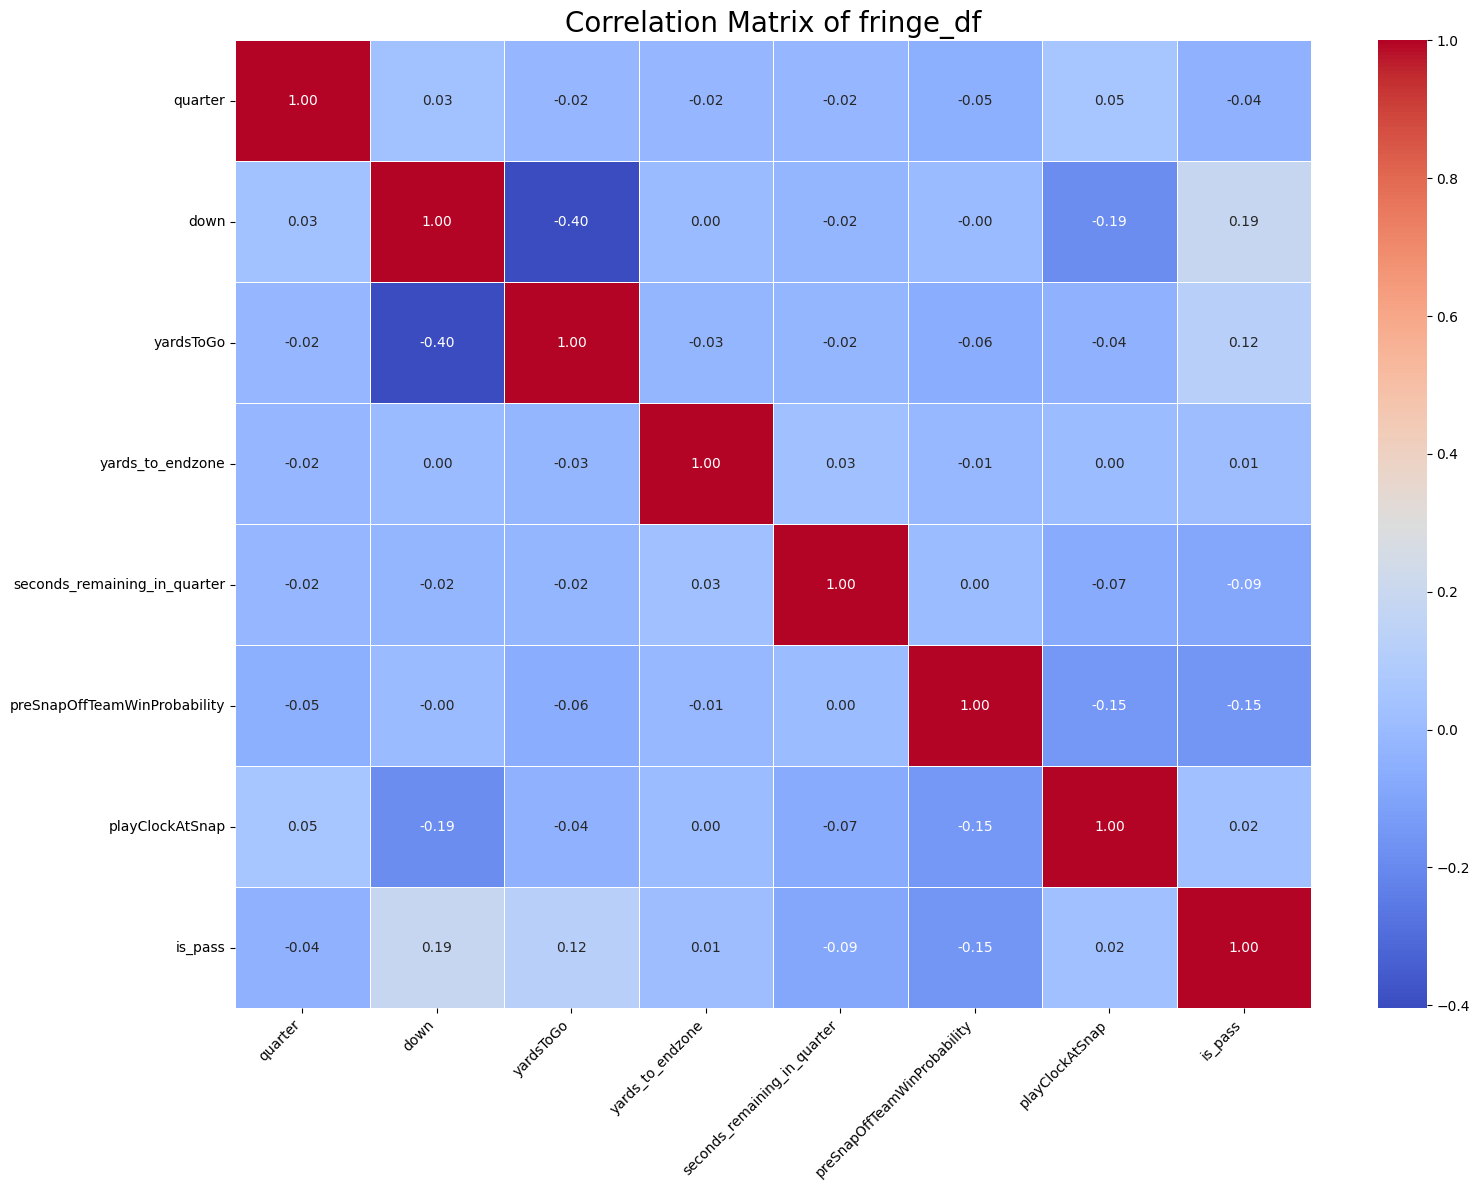

In [7]:
fringe_df = get_fringe_df(40, 55) # Define fringe_df here

# Calculate the correlation matrix
correlation_matrix = fringe_df.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of fringe_df', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This correlation analysis helps understand how the different variables are related and which would be helpful for modeling. In our case we take all of them.

## Training and Evaluation Results



Running 5-Fold Cross Validation with undersampling...


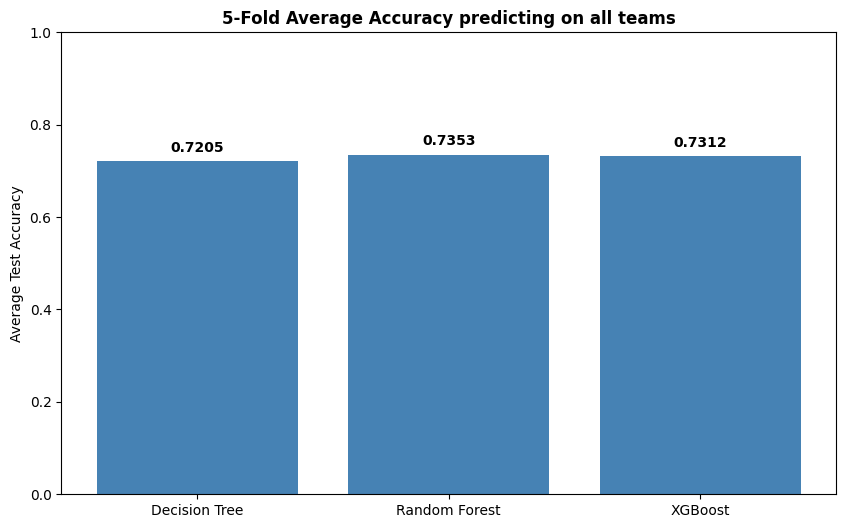

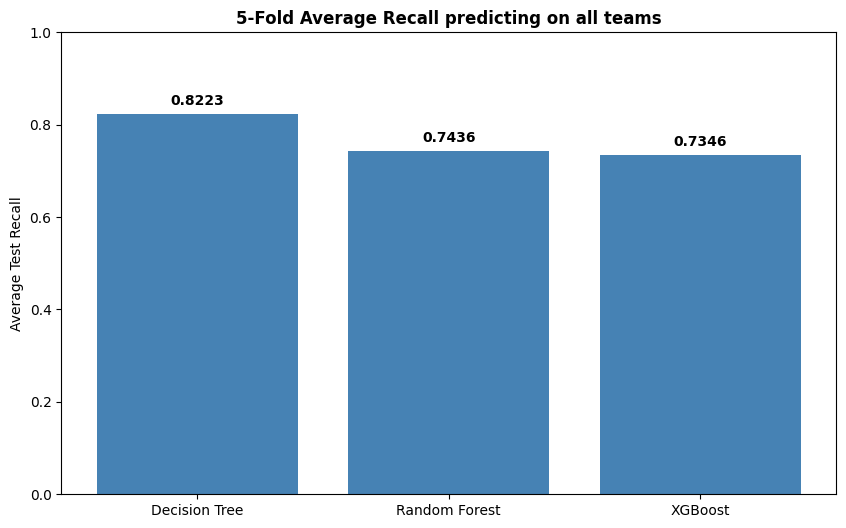

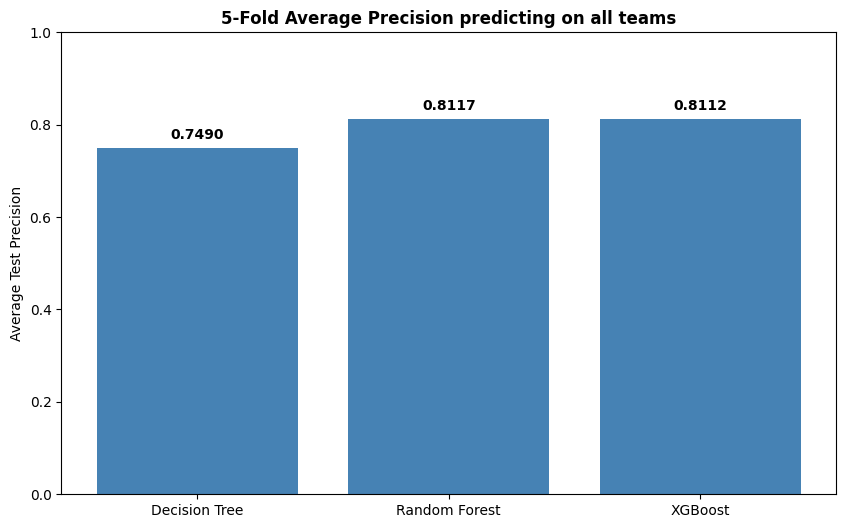

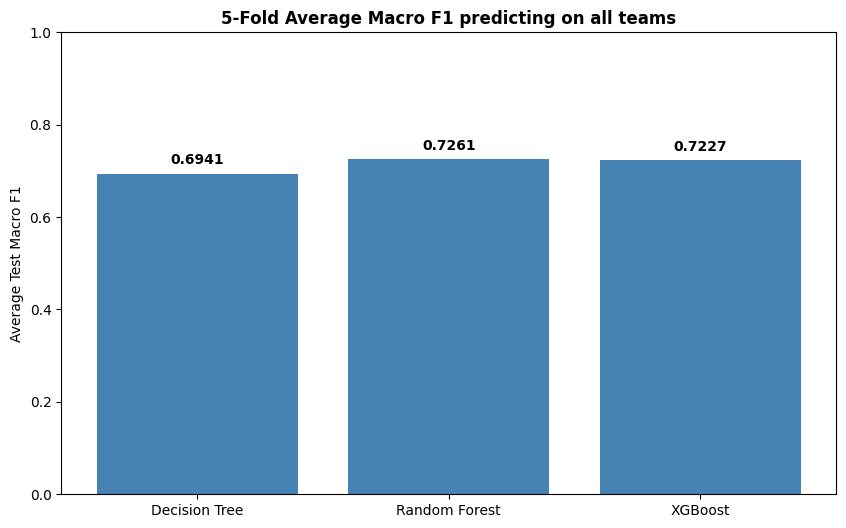

In [36]:
# Ensure fringe_df is available
fringe_df = get_fringe_df(40, 55)
X_all = fringe_df.drop(columns=['is_pass'])
y_all = fringe_df['is_pass']

categorical = ["possessionTeam", "defensiveTeam", "offenseFormation", "receiverAlignment"]
numeric = ["quarter", "down", "yardsToGo", "yards_to_endzone", "preSnapOffTeamWinProbability", "seconds_remaining_in_quarter", "playClockAtSnap"]

# Set up 5-fold cross validation
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=117)

metrics = {
    'Decision Tree': {'accuracy': [], 'recall': [], 'precision': [], 'f1': []},
    'Random Forest': {'accuracy': [], 'recall': [], 'precision': [], 'f1': []},
    'XGBoost': {'accuracy': [], 'recall': [], 'precision': [], 'f1': []}
}

print("Running 5-Fold Cross Validation with undersampling...")
for train_index, test_index in sss.split(X_all, y_all):
    train_df = fringe_df.iloc[train_index]
    test_df = fringe_df.iloc[test_index]

    # Balance the training set
    pass_plays = train_df[train_df['is_pass'] == 1]
    run_plays = train_df[train_df['is_pass'] == 0]
    min_samples = min(len(pass_plays), len(run_plays))

    balanced_train_df = pd.concat([
        pass_plays.sample(min_samples, random_state=42),
        run_plays.sample(min_samples, random_state=42)
    ]).sample(frac=1, random_state=117)

    X_train_raw = balanced_train_df.drop(columns=['is_pass'])
    y_train = balanced_train_df['is_pass']

    X_test_raw = test_df.drop(columns=['is_pass'])
    y_test = test_df['is_pass']

    # Define pipelines
    dt_pipeline, rf_random_search, xgb_random_search = define_dt_rf_xgb_pipelines(categorical, numeric)

    # Fit Models
    dt_pipeline.fit(X_train_raw, y_train)
    rf_random_search.fit(X_train_raw, y_train)
    xgb_random_search.fit(X_train_raw, y_train)

    # Predict
    dt_pred = dt_pipeline.predict(X_test_raw)
    rf_pred = rf_random_search.predict(X_test_raw)
    xgb_pred = xgb_random_search.predict(X_test_raw)

    # Record metrics
    metrics['Decision Tree']['accuracy'].append(accuracy_score(y_test, dt_pred))
    metrics['Decision Tree']['recall'].append(recall_score(y_test, dt_pred))
    metrics['Decision Tree']['precision'].append(precision_score(y_test, dt_pred))
    metrics['Decision Tree']['f1'].append(f1_score(y_test, dt_pred, average='macro'))

    metrics['Random Forest']['accuracy'].append(accuracy_score(y_test, rf_pred))
    metrics['Random Forest']['recall'].append(recall_score(y_test, rf_pred))
    metrics['Random Forest']['precision'].append(precision_score(y_test, rf_pred))
    metrics['Random Forest']['f1'].append(f1_score(y_test, rf_pred, average='macro'))

    metrics['XGBoost']['accuracy'].append(accuracy_score(y_test, xgb_pred))
    metrics['XGBoost']['recall'].append(recall_score(y_test, xgb_pred))
    metrics['XGBoost']['precision'].append(precision_score(y_test, xgb_pred))
    metrics['XGBoost']['f1'].append(f1_score(y_test, xgb_pred, average='macro'))

# Calculate Averages
avg_metrics = {
    model: {
        m: np.mean(vals) for m, vals in metrics[model].items()
    } for model in metrics
}

# Plotting Bar Charts
models = ['Decision Tree', 'Random Forest', 'XGBoost']
metric_names = ['accuracy', 'recall', 'precision', 'f1']
chart_titles = ['Accuracy', 'Recall', 'Precision', 'Macro F1']

for m_name, title in zip(metric_names, chart_titles):
    scores = [avg_metrics[model][m_name] for model in models]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, scores, color='steelblue')
    plt.ylabel(f'Average Test {title}')
    plt.title(f'5-Fold Average {title} predicting on all teams', fontweight='bold')
    plt.ylim(0, 1.0)

    # Add labels on top of bars
    for bar in bars:
        v = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

    plt.show()


Takeaway: We can predict pass or play decently well across all teams!

These results will be used as baselines to compare the prediction performance of the team level models.

### Permutation Importances

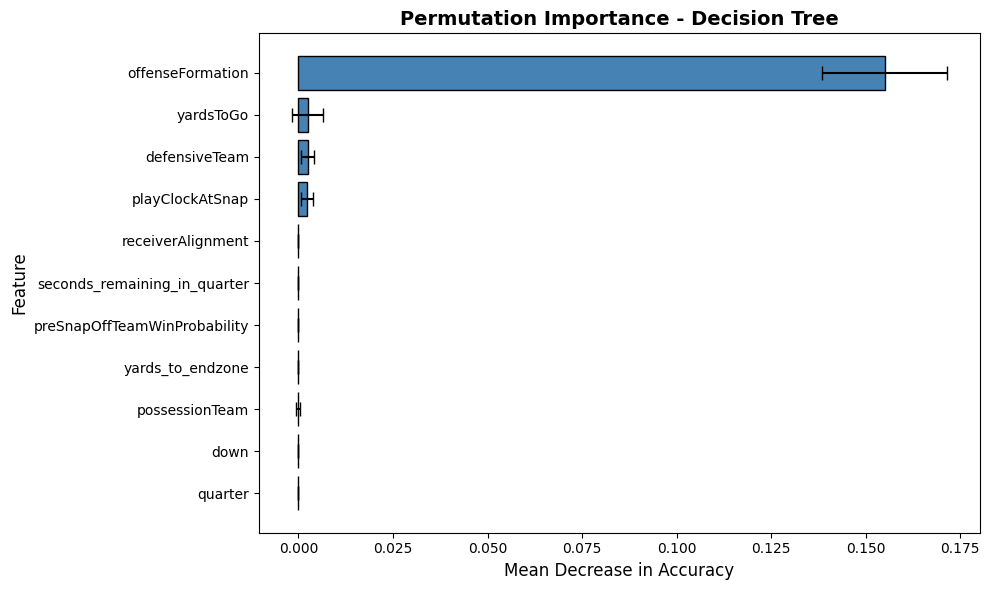

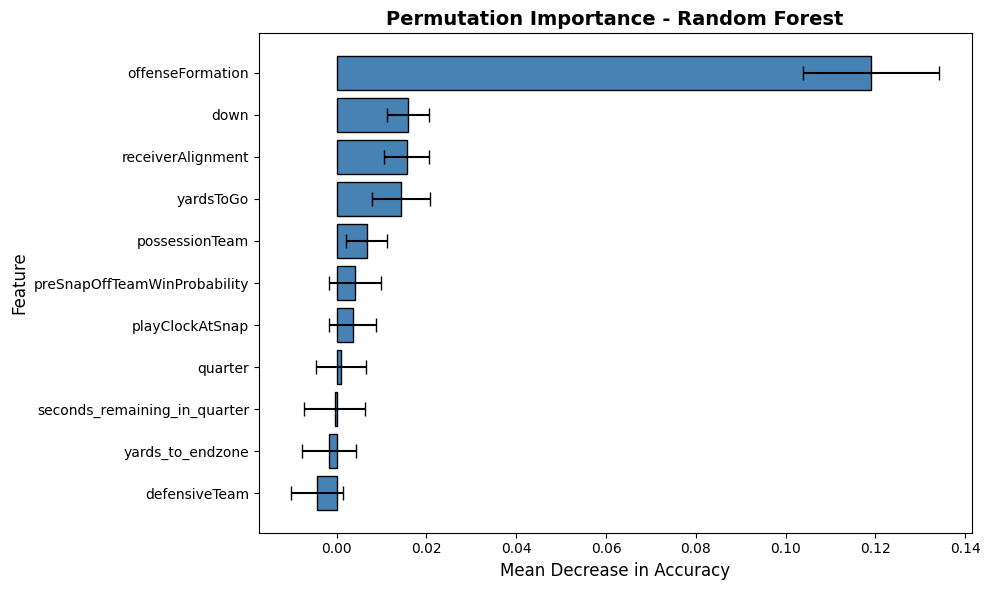

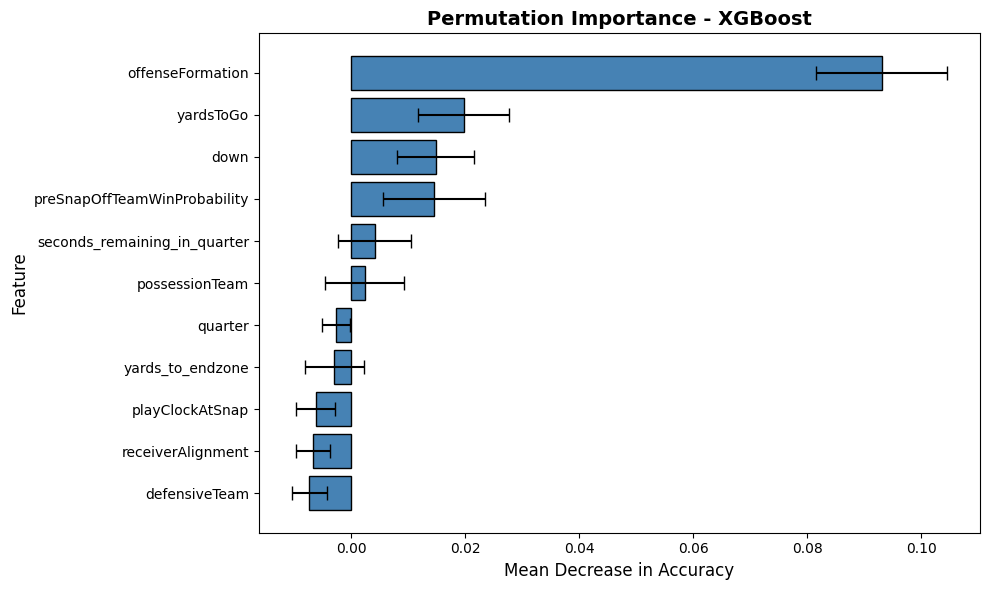

In [11]:
# Dictionary of our trained models for the entire league
models_dict = {
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_random_search.best_estimator_,
    'XGBoost': xgb_random_search.best_estimator_
}

for name, model in models_dict.items():
    # Calculate permutation importance on the test set
    # n_repeats=10 means it will shuffle each feature 10 times to compute the average drop in performance
    result = permutation_importance(model, X_test_raw, y_test, n_repeats=10, random_state=42, n_jobs=-1)

    # Create a DataFrame for easier plotting
    imp_df = pd.DataFrame({
        'Feature': X_test_raw.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std
    })

    # Sort by importance
    imp_df = imp_df.sort_values(by='Importance', ascending=True)

    # Plot bar chart
    plt.figure(figsize=(10, 6))
    plt.barh(imp_df['Feature'], imp_df['Importance'], xerr=imp_df['Std'], color='steelblue', edgecolor='black', capsize=5)
    plt.title(f'Permutation Importance - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Mean Decrease in Accuracy', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

Permutation importances are calculated by shuffling the values of a certain feature and then evaluating the impact that it has on a the prediction performance on the test dataset. We set the n_repeats variable equal to 10, which means that they permute each feature and evaluate the results 10 times. The final permutation importance for each variable is the average decrease in each indicated metric.

These importances are telling of how the model predicts what it is able to predict.

# Individual Team Predictions

Now that we know that we can predict generally across all teams, let's see if we can do it for each individual team! This way we can see if some teams are more predictable than others.

## Data Preprocessing, Model Fitting, and Inference on Test Set

In [12]:
def team_filter(df, team_abbr):
    team_df = df[df["possessionTeam"] == team_abbr]
    team_df.to_csv(f'{team_abbr}.csv', index=None)

    return team_df

In [13]:
categorical = ["defensiveTeam", "offenseFormation", "receiverAlignment"]
numeric = ["quarter", "down", "yardsToGo", "yards_to_endzone", "preSnapOffTeamWinProbability", "seconds_remaining_in_quarter", "playClockAtSnap"]

# Create a directory to save the trained models
os.makedirs('saved_team_models', exist_ok=True)

cols = [
    'team',
    'dt_accuracy',
    'dt_recall',
    'dt_precision',
    'dt_f1',
    'dt_loss',
    'rf_accuracy',
    'rf_recall',
    'rf_precision',
    'rf_f1',
    'rf_loss',
    'xgb_accuracy',
    'xgb_recall',
    'xgb_precision',
    'xgb_f1',
    'xgb_loss',
    'size_train_df',
    'size_test_df',
]

team_performance_df = pd.DataFrame(columns=cols)

for team_abbr in plays_df["possessionTeam"].unique():
    print("==============================================================================")
    print("==============================================================================")
    print(team_abbr)
    print("==============================================================================")
    print("==============================================================================")

    # Data Preprocessing
    team_plays_df = team_filter(plays_df, team_abbr)
    team_fringe_df = get_fringe_df(40, 55, team_plays_df)
    team_fringe_df = team_fringe_df.drop(columns=["possessionTeam"])

    X_all = team_fringe_df.drop(columns=['is_pass'])
    y_all = team_fringe_df['is_pass']

    # Check if we have enough data for 5-fold CV
    if len(y_all) < 10 or min(y_all.value_counts()) < 5:
        print(f"Skipping {team_abbr} due to insufficient data for 5 folds.")
        continue

    # Set up 5-fold cross validation with 80/20 split roughly
    sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=117)

    dt_metrics = {'acc': [], 'rec': [], 'prec': [], 'f1': [], 'loss': []}
    rf_metrics = {'acc': [], 'rec': [], 'prec': [], 'f1': [], 'loss': []}
    xgb_metrics = {'acc': [], 'rec': [], 'prec': [], 'f1': [], 'loss': []}

    train_sizes, test_sizes = [], []

    fold = 1
    for train_index, test_index in sss.split(X_all, y_all):
        # Create split dataframes
        train_df = team_fringe_df.iloc[train_index]
        test_df = team_fringe_df.iloc[test_index]

        # Balance the training set by undersampling
        pass_plays = train_df[train_df['is_pass'] == 1]
        run_plays = train_df[train_df['is_pass'] == 0]
        min_samples = min(len(pass_plays), len(run_plays))

        if min_samples == 0:
             continue

        balanced_train_df = pd.concat([
            pass_plays.sample(min_samples, random_state=42),
            run_plays.sample(min_samples, random_state=42)
        ]).sample(frac=1, random_state=117) # Shuffle

        X_train_raw = balanced_train_df.drop(columns=['is_pass'])
        y_train = balanced_train_df['is_pass']

        X_test_raw = test_df.drop(columns=['is_pass'])
        y_test = test_df['is_pass']

        train_sizes.append(len(balanced_train_df))
        test_sizes.append(len(test_df))

        # Define pipelines
        dt_pipeline, rf_random_search, xgb_random_search = define_dt_rf_xgb_pipelines(categorical, numeric)

        # Fit pipelines
        dt_pipeline.fit(X_train_raw, y_train)
        rf_random_search.fit(X_train_raw, y_train)
        xgb_random_search.fit(X_train_raw, y_train)

        # Evaluate Models (Predict on test fold)
        dt_pred = dt_pipeline.predict(X_test_raw)
        dt_pred_proba = dt_pipeline.predict_proba(X_test_raw)
        dt_metrics['acc'].append(accuracy_score(y_test, dt_pred))
        dt_metrics['rec'].append(recall_score(y_test, dt_pred, zero_division=0))
        dt_metrics['prec'].append(precision_score(y_test, dt_pred, zero_division=0))
        dt_metrics['f1'].append(f1_score(y_test, dt_pred, average='macro'))
        dt_metrics['loss'].append(log_loss(y_test, dt_pred_proba, labels=[0, 1]))

        rf_pred = rf_random_search.predict(X_test_raw)
        rf_pred_proba = rf_random_search.predict_proba(X_test_raw)
        rf_metrics['acc'].append(accuracy_score(y_test, rf_pred))
        rf_metrics['rec'].append(recall_score(y_test, rf_pred, zero_division=0))
        rf_metrics['prec'].append(precision_score(y_test, rf_pred, zero_division=0))
        rf_metrics['f1'].append(f1_score(y_test, rf_pred, average='macro'))
        rf_metrics['loss'].append(log_loss(y_test, rf_pred_proba, labels=[0, 1]))

        xgb_pred = xgb_random_search.predict(X_test_raw)
        xgb_pred_proba = xgb_random_search.predict_proba(X_test_raw)
        xgb_metrics['acc'].append(accuracy_score(y_test, xgb_pred))
        xgb_metrics['rec'].append(recall_score(y_test, xgb_pred, zero_division=0))
        xgb_metrics['prec'].append(precision_score(y_test, xgb_pred, zero_division=0))
        xgb_metrics['f1'].append(f1_score(y_test, xgb_pred, average='macro'))
        xgb_metrics['loss'].append(log_loss(y_test, xgb_pred_proba, labels=[0, 1]))

        fold += 1

    # We will save the model from the last fold for permutation importance later
    joblib.dump(dt_pipeline, f'saved_team_models/{team_abbr}_dt_pipeline.pkl')
    joblib.dump(rf_random_search.best_estimator_, f'saved_team_models/{team_abbr}_rf_pipeline.pkl')
    joblib.dump(xgb_random_search.best_estimator_, f'saved_team_models/{team_abbr}_xgb_pipeline.pkl')

    # Append average metrics to the performance dataframe
    if dt_metrics['acc']:
        team_performance_df.loc[len(team_performance_df)] = [
            team_abbr,
            np.mean(dt_metrics['acc']), np.mean(dt_metrics['rec']), np.mean(dt_metrics['prec']), np.mean(dt_metrics['f1']), np.mean(dt_metrics['loss']),
            np.mean(rf_metrics['acc']), np.mean(rf_metrics['rec']), np.mean(rf_metrics['prec']), np.mean(rf_metrics['f1']), np.mean(rf_metrics['loss']),
            np.mean(xgb_metrics['acc']), np.mean(xgb_metrics['rec']), np.mean(xgb_metrics['prec']), np.mean(xgb_metrics['f1']), np.mean(xgb_metrics['loss']),
            np.mean(train_sizes), np.mean(test_sizes)
        ]

    print(f"Finished evaluating {team_abbr}.")
    print()

display(team_performance_df)


CIN
Finished evaluating CIN.

HOU
Finished evaluating HOU.

KC
Finished evaluating KC.

BAL
Finished evaluating BAL.

DET
Finished evaluating DET.

IND
Finished evaluating IND.

ARI
Finished evaluating ARI.

PHI
Finished evaluating PHI.

DAL
Finished evaluating DAL.

GB
Finished evaluating GB.

ATL
Finished evaluating ATL.

LV
Finished evaluating LV.

WAS
Finished evaluating WAS.

TEN
Finished evaluating TEN.

NE
Finished evaluating NE.

LAC
Finished evaluating LAC.

SEA
Finished evaluating SEA.

CLE
Finished evaluating CLE.

JAX
Finished evaluating JAX.

TB
Finished evaluating TB.

LA
Finished evaluating LA.

MIA
Finished evaluating MIA.

CHI
Finished evaluating CHI.

NO
Finished evaluating NO.

CAR
Finished evaluating CAR.

BUF
Finished evaluating BUF.

SF
Finished evaluating SF.

MIN
Finished evaluating MIN.

PIT
Finished evaluating PIT.

NYJ
Finished evaluating NYJ.

NYG
Finished evaluating NYG.

DEN
Finished evaluating DEN.



,team,dt_accuracy,dt_recall,dt_precision,dt_f1,dt_loss,rf_accuracy,rf_recall,rf_precision,rf_f1,rf_loss,xgb_accuracy,xgb_recall,xgb_precision,xgb_f1,xgb_loss,size_train_df,size_test_df
0,CIN,0.789474,0.833333,0.848810,0.766834,3.713541,0.747368,0.766667,0.844786,0.727282,0.548123,0.789474,0.833333,0.850010,0.770117,0.543065,56.0,19.0
1,HOU,0.525000,0.500000,0.609271,0.509902,3.735346,0.675000,0.740000,0.745000,0.651025,0.657937,0.637500,0.680000,0.711429,0.615891,0.706855,50.0,16.0
2,KC,0.409524,0.400000,0.662500,0.360561,9.079564,0.580952,0.562500,0.849679,0.536839,0.668615,0.514286,0.525000,0.758531,0.469856,0.881975,38.0,21.0
3,BAL,0.663158,0.533333,0.638889,0.642327,1.699157,0.757895,0.644444,0.805635,0.750158,0.573320,0.694737,0.644444,0.692222,0.690437,0.635999,74.0,19.0
4,DET,0.684211,0.740000,0.716031,0.667036,3.543840,0.726316,0.740000,0.762904,0.719750,0.570127,0.694737,0.620000,0.766883,0.691767,0.610414,72.0,19.0
5,IND,0.691667,0.725000,0.804224,0.659120,5.192629,0.691667,0.762500,0.776984,0.647802,0.635685,0.625000,0.612500,0.791078,0.604814,0.841616,62.0,24.0
6,ARI,0.620000,0.600000,0.719408,0.614237,2.386092,0.580000,0.583333,0.678632,0.570040,0.673852,0.600000,0.600000,0.722168,0.587554,0.689409,62.0,20.0
7,PHI,0.588889,0.654545,0.676966,0.548487,6.450022,0.600000,0.636364,0.691290,0.583118,0.653539,0.588889,0.527273,0.729978,0.584634,0.736870,56.0,18.0
8,DAL,0.633333,0.545455,0.830909,0.610455,4.486389,0.733333,0.709091,0.849192,0.723760,0.574092,0.755556,0.727273,0.850152,0.749614,0.605393,50.0,18.0
9,GB,0.592000,0.573333,0.744608,0.549376,1.519789,0.560000,0.493333,0.684638,0.554835,0.674839,0.584000,0.506667,0.713248,0.578599,0.730083,74.0,25.0


**Preprocessing**\
The preprocessing for each individual team is the same as it was across all teams in the section above. The only difference is that it doesn't include which team has the ball (as this is inherent in the data).

**Training**\
We train the same 3 models and do the same hyperparameter tuning as with the model above.

**Evaluation**\
We evaluate these models also with a 5 folds cross validation on the same metrics as above.

## Evaluation Results

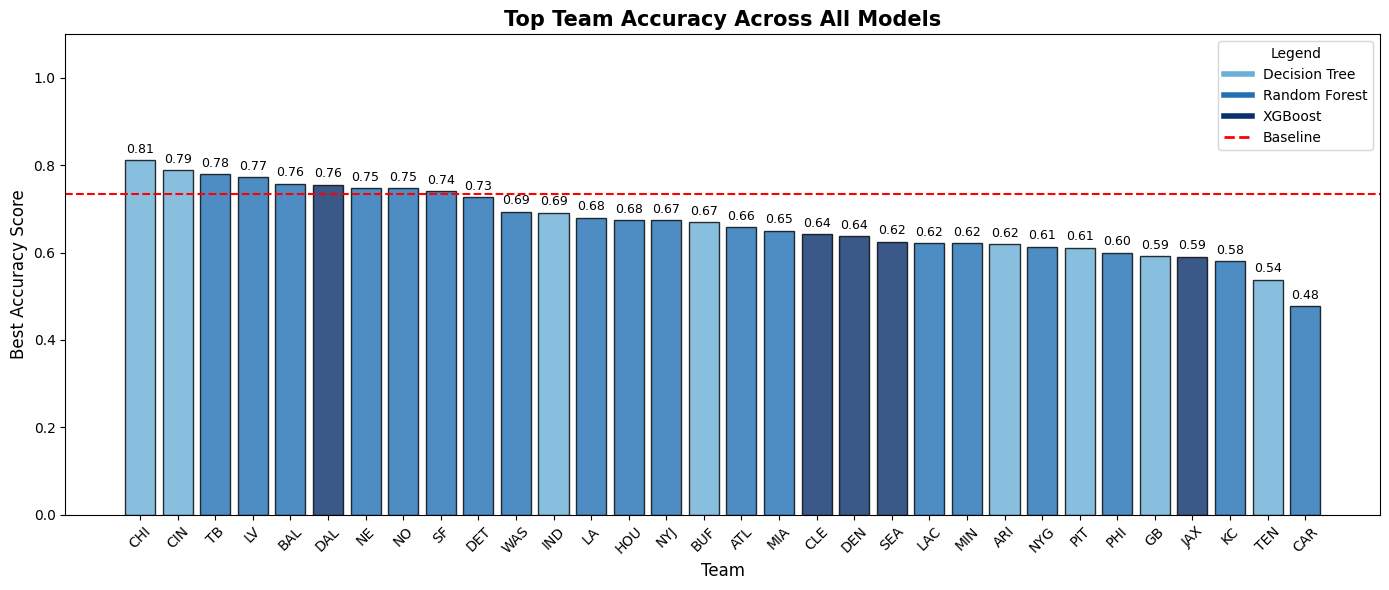

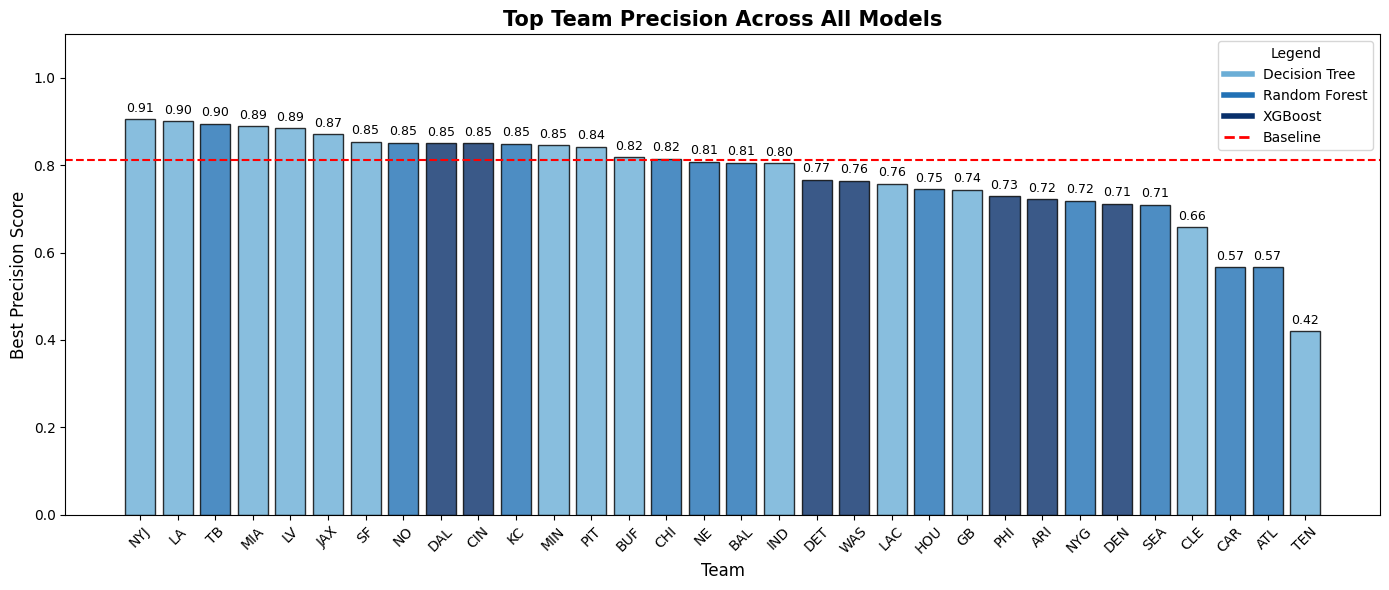

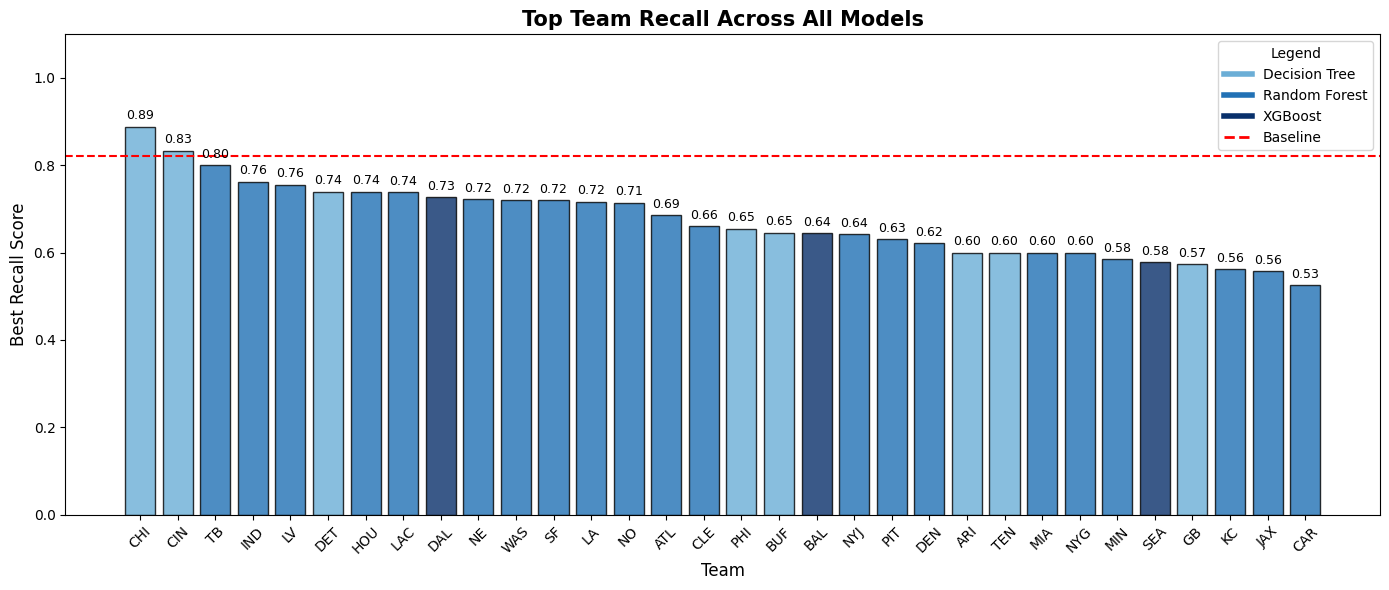

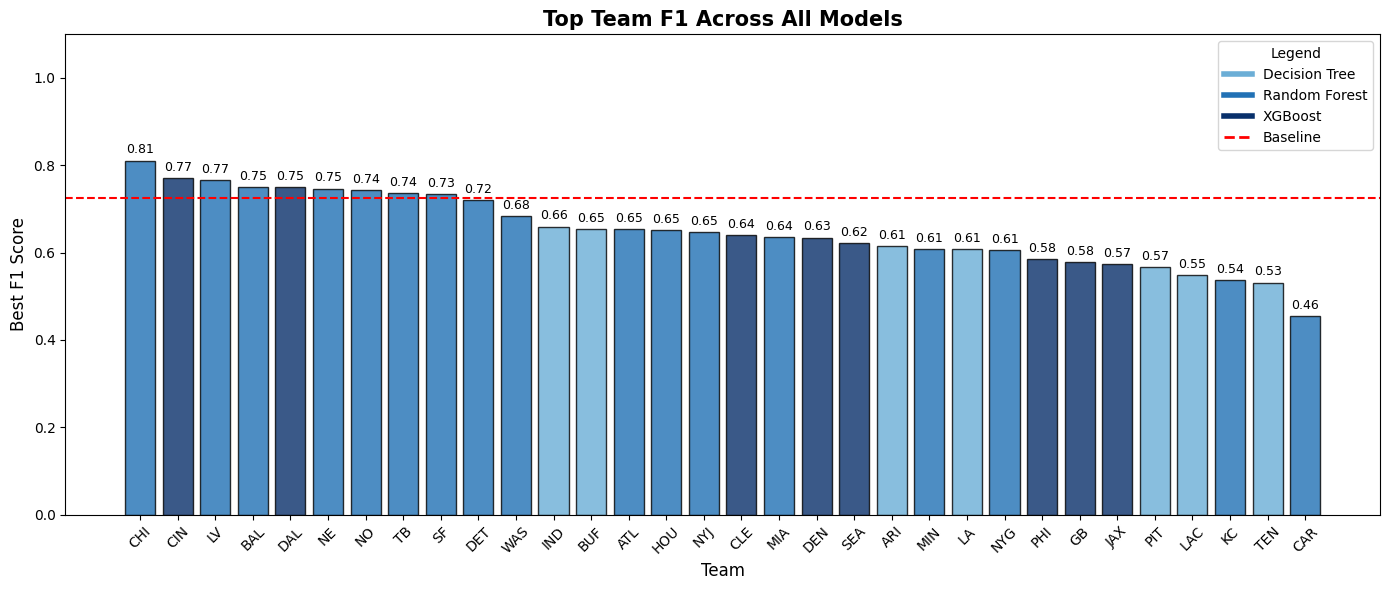

In [37]:
# Define the metrics we want to visualize
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
models = ['dt', 'rf', 'xgb']
model_names = {'dt': 'Decision Tree', 'rf': 'Random Forest', 'xgb': 'XGBoost'}
colors = {'dt': '#6baed6', 'rf': '#2171b5', 'xgb': '#08306b'}

# Extract baselines from avg_metrics dynamically
baselines = {}
for metric in metrics_list:
    best_val = max(avg_metrics[model_key][metric] for model_key in avg_metrics)
    baselines[metric] = best_val

for metric in metrics_list:
    # Identify columns for this metric across models (e.g., dt_accuracy, rf_accuracy, xgb_accuracy)
    metric_cols = [f'{m}_{metric}' for m in models]

    # Find the best model and value for each team
    best_values = team_performance_df[metric_cols].max(axis=1)
    best_model_indices = team_performance_df[metric_cols].idxmax(axis=1)
    best_models = best_model_indices.apply(lambda x: x.split('_')[0])

    # Create a temporary plotting dataframe
    plot_df = pd.DataFrame({
        'team': team_performance_df['team'],
        'value': best_values,
        'model': best_models
    }).sort_values('value', ascending=False)

    plt.figure(figsize=(14, 6))

    # Map colors based on the best model
    bar_colors = [colors[m] for m in plot_df['model']]

    bars = plt.bar(plot_df['team'], plot_df['value'], color=bar_colors, edgecolor='black', alpha=0.8)

    plt.title(f'Top Team {metric.capitalize()} Across All Models', fontsize=15, fontweight='bold')
    plt.xlabel('Team', fontsize=12)
    plt.ylabel(f'Best {metric.capitalize()} Score', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, 1.1)

    # Add baseline if applicable
    if metric in baselines:
        val = baselines[metric]
        plt.axhline(y=val, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({val:.4f})')
        # plt.text(len(plot_df)-1, val + 0.01, 'Baseline', color='red', fontweight='bold', ha='right', va='bottom')

    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=colors[m], lw=4, label=model_names[m]) for m in models]
    if metric in baselines:
        legend_elements.append(Line2D([0], [0], color='red', linestyle='--', lw=2, label='Baseline'))

    plt.legend(handles=legend_elements, title='Legend', loc='upper right')

    # Add value labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=9, rotation=0)

    plt.tight_layout()
    plt.show()


This shows the metrics for each team's best performing model for each metric, along with the baseline value from the general model above.

**Takeaway:** Some teams are more predictable than others! In the Top Team F1 Across All Models chart we see that the Chicago Bears are much more predictable than the Carolina Panthers. Knowing that, defensive coaches can prepare better for the more predictable teams by knowing that they can rely on the data and the model predictions better.

As a side note, these models were trained on very little amounts of data (max ~70 plays of data). We believe that given more data, we will see an increase in performance across all teams' models.

### Permutation Importances


=== Permutation Importances for Team: CHI ===
=== Best Model: Random Forest (F1: 0.8105) ===

Original training size: 69
Balanced training size: 66
Processed feature shape: (66, 11)
Test set size: 18


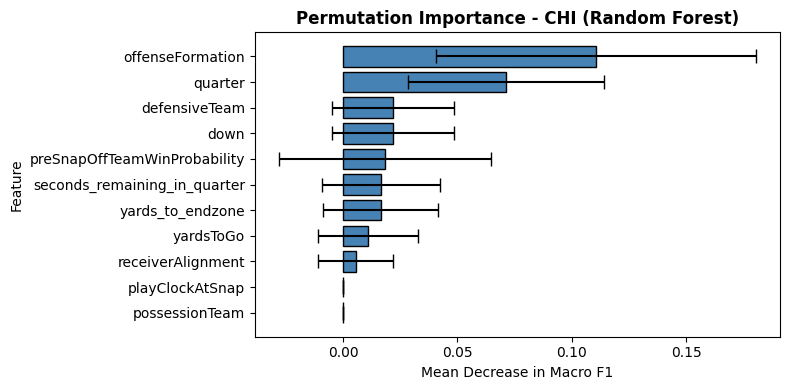


=== Permutation Importances for Team: CIN ===
=== Best Model: XGBoost (F1: 0.7701) ===

Original training size: 75
Balanced training size: 56
Processed feature shape: (56, 11)
Test set size: 19


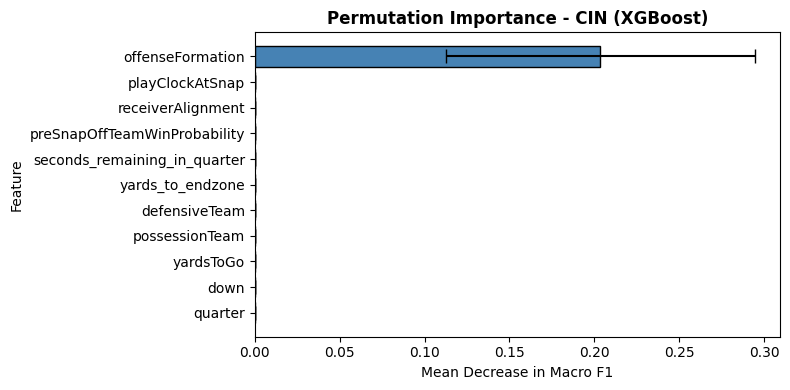


=== Permutation Importances for Team: LV ===
=== Best Model: Random Forest (F1: 0.7665) ===

Original training size: 59
Balanced training size: 48
Processed feature shape: (48, 11)
Test set size: 15


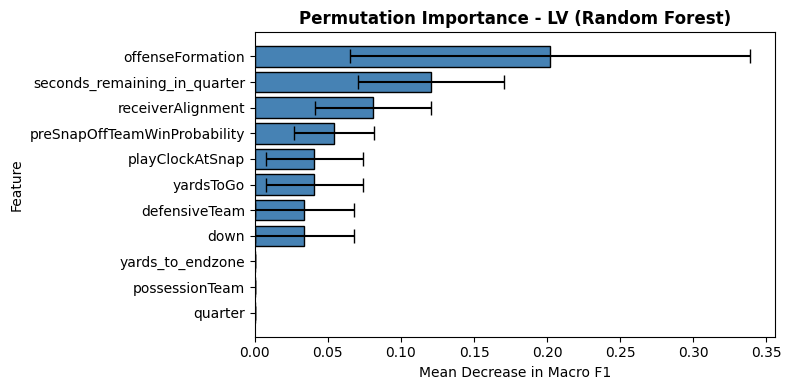


=== Permutation Importances for Team: BAL ===
=== Best Model: Random Forest (F1: 0.7502) ===

Original training size: 75
Balanced training size: 74
Processed feature shape: (74, 11)
Test set size: 19


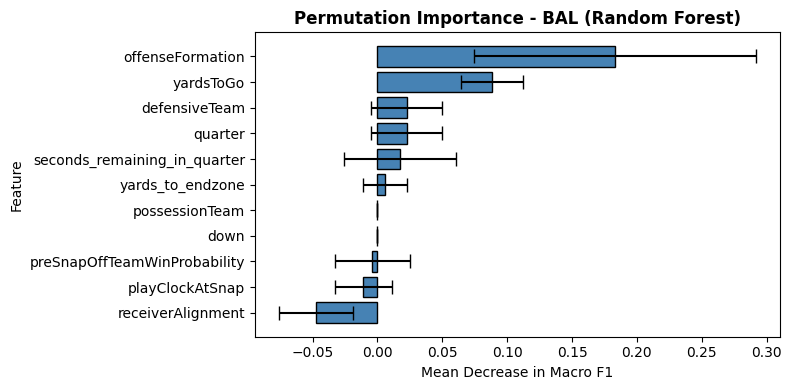


=== Permutation Importances for Team: DAL ===
=== Best Model: XGBoost (F1: 0.7496) ===

Original training size: 70
Balanced training size: 50
Processed feature shape: (50, 11)
Test set size: 18


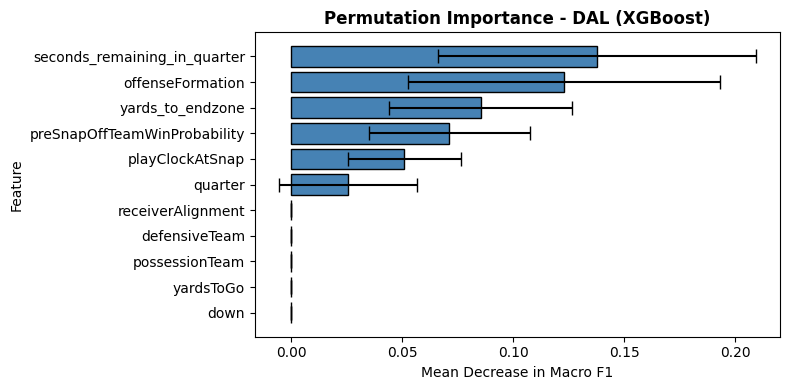

In [26]:
# Identify the best F1 score and the corresponding model for each team
f1_cols = ['dt_f1', 'rf_f1', 'xgb_f1']
team_performance_df['best_f1'] = team_performance_df[f1_cols].max(axis=1)
team_performance_df['best_f1_model'] = team_performance_df[f1_cols].idxmax(axis=1).apply(lambda x: x.split('_')[0])

# Get the top 5 teams based on the best F1 score
top_5_teams_df = team_performance_df.nlargest(5, 'best_f1')

model_names = {'dt': 'Decision Tree', 'rf': 'Random Forest', 'xgb': 'XGBoost'}

# Dictionary to store the permutation importances for the top 5 teams
top_5_importances = {}

for index, row in top_5_teams_df.iterrows():
    team_abbr = row['team']
    best_model_prefix = row['best_f1_model']
    best_f1_score = row['best_f1']

    print("\n" + "="*80)
    print(f"=== Permutation Importances for Team: {team_abbr} ===")
    print(f"=== Best Model: {model_names[best_model_prefix]} (F1: {best_f1_score:.4f}) ===")
    print("="*80 + "\n")

    # Recreate test data for the team
    team_plays_df = team_filter(plays_df, team_abbr)
    team_fringe_df = get_fringe_df(40, 55, team_plays_df)

    # Get the exact splits
    _, X_test_raw, _, y_test, _, _ = cleaning_fringe_df(team_fringe_df, 'is_pass')

    model_path = f'saved_team_models/{team_abbr}_{best_model_prefix}_pipeline.pkl'

    if os.path.exists(model_path):
        # Load the fitted model pipeline
        model = joblib.load(model_path)

        # Calculate permutation importance using Macro F1
        result = permutation_importance(model, X_test_raw, y_test, scoring='f1_macro', n_repeats=10, random_state=42, n_jobs=-1)

        # Prepare DataFrame for visualization
        imp_df = pd.DataFrame({
            'Feature': X_test_raw.columns,
            'Importance': result.importances_mean,
            'Std': result.importances_std
        }).sort_values(by='Importance', ascending=True)

        # Store the importance dataframe for future use
        top_5_importances[team_abbr] = imp_df

        # Plot
        plt.figure(figsize=(8, 4))
        plt.barh(imp_df['Feature'], imp_df['Importance'], xerr=imp_df['Std'], color='steelblue', edgecolor='black', capsize=5)
        plt.title(f'Permutation Importance - {team_abbr} ({model_names[best_model_prefix]})', fontsize=12, fontweight='bold')
        plt.xlabel('Mean Decrease in Macro F1', fontsize=10)
        plt.ylabel('Feature', fontsize=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f"[Warning] Model file not found: {model_path}")


We use these permutation importances of each team (in the case above, they are the top 5 most predictable teams) to guide an analysis of **what is predictable about them**. Understanding that a team is predictable according to the data is helpful for a defense, but by digging into the data more we can understand more what signals they give that helps the model predict what they are going to do before they do it.

# Analysis of Predictable and Non-Predictable Teams

Here we dig more into **what is predictable or not predictable about these different teams. We compare the most predictable team (Chicago Bears) with the least predictable team (Carolina Panthers).

## Most Predictable Team

Most Predictable Team: CHI
Highest Macro F1: 0.8105 (Model: RF)


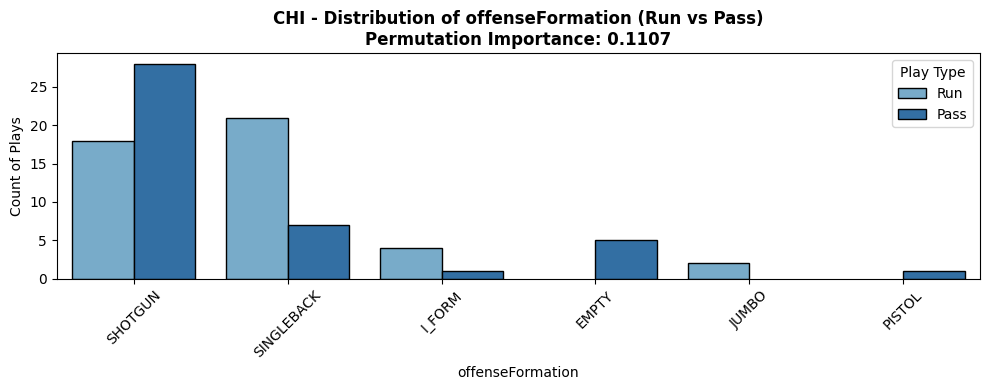

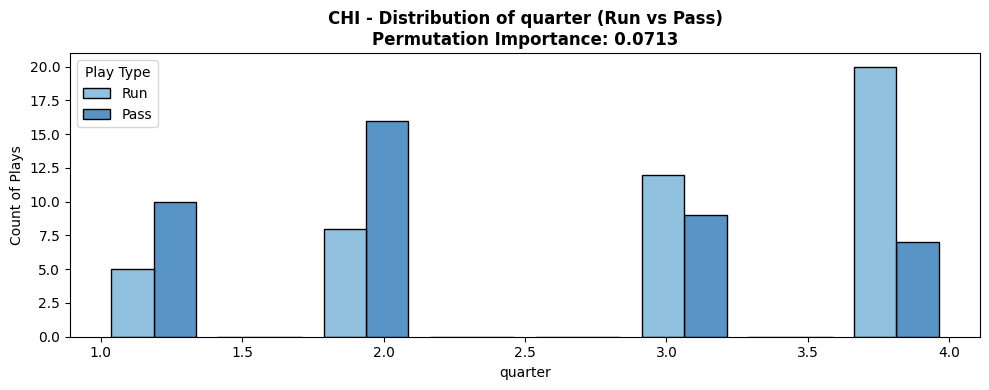

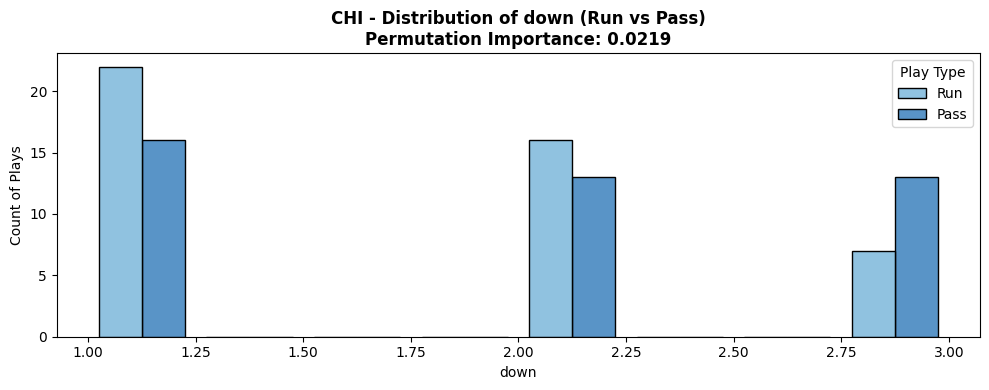

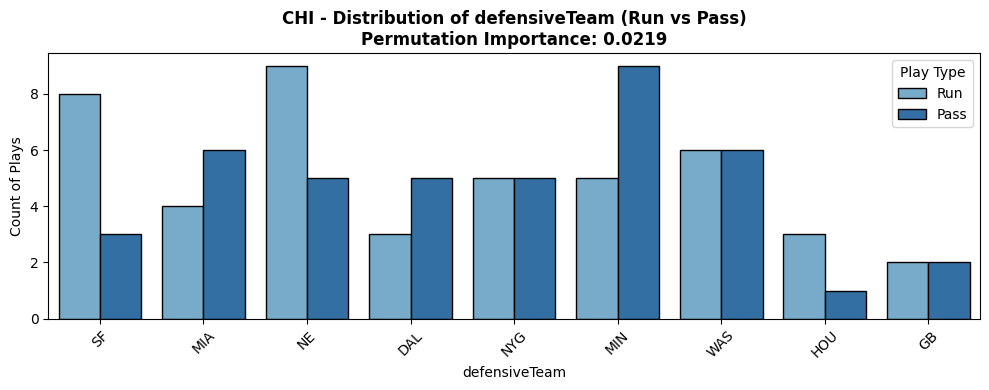

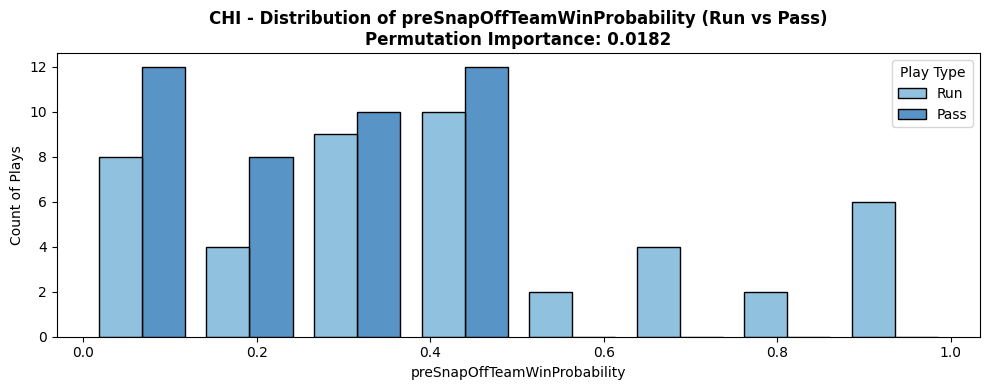

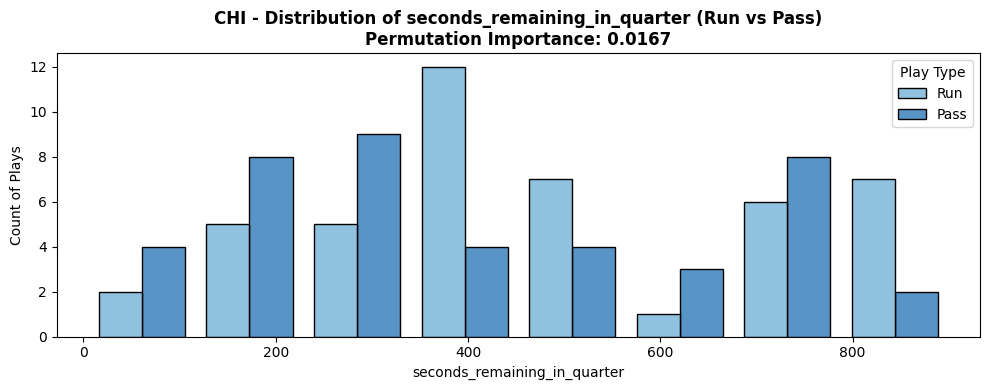

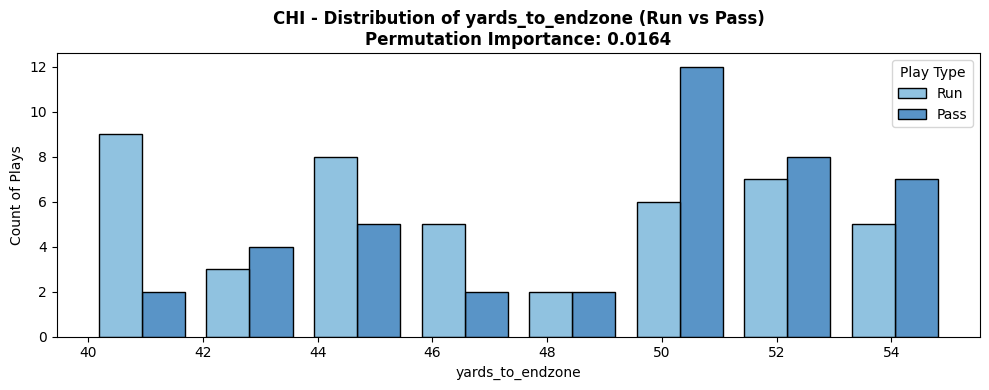

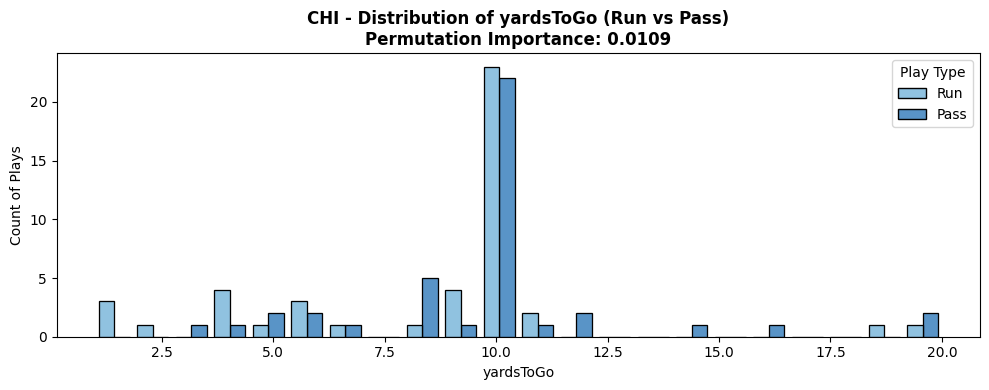

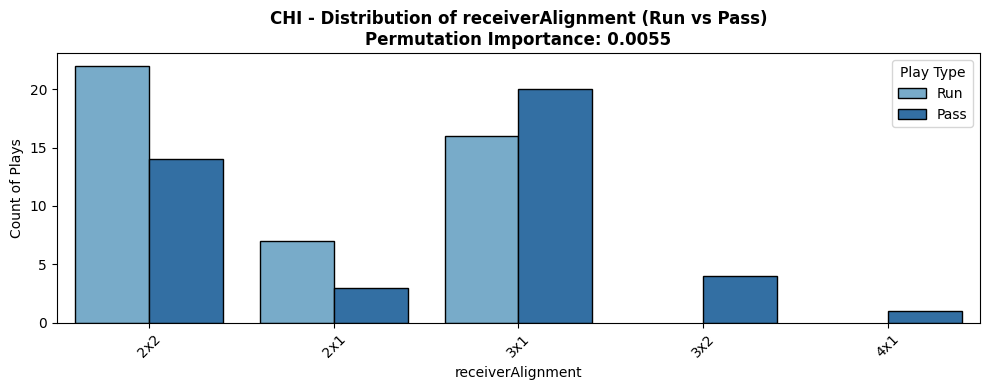

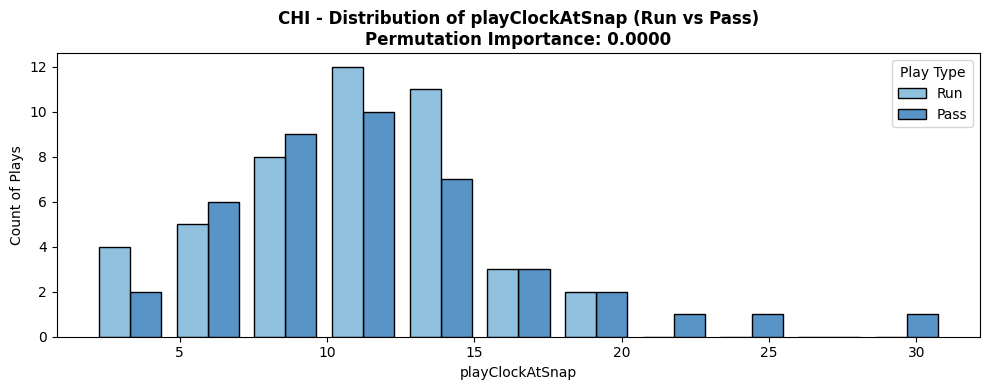

<Figure size 1000x400 with 0 Axes>

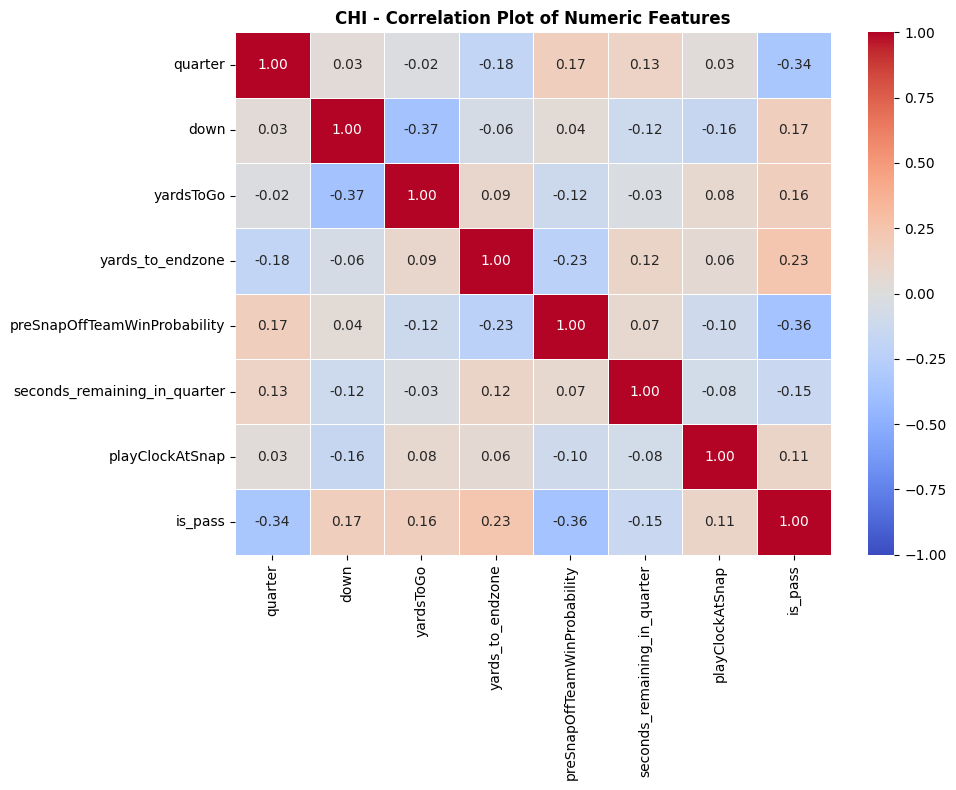

In [34]:
# Find the team with the highest F1 score overall
f1_cols = ['dt_f1', 'rf_f1', 'xgb_f1']
# Create a temporary column for the max F1 score across the three models
team_performance_df['max_overall_f1'] = team_performance_df[f1_cols].max(axis=1)

# Get the row of the most predictable team
best_team_row = team_performance_df.loc[team_performance_df['max_overall_f1'].idxmax()]
best_team = best_team_row['team']
best_f1 = best_team_row['max_overall_f1']
best_model = f1_cols[team_performance_df.loc[team_performance_df['max_overall_f1'].idxmax(), f1_cols].astype(float).argmax()].split('_')[0]

print(f"Most Predictable Team: {best_team}")
print(f"Highest Macro F1: {best_f1:.4f} (Model: {best_model.upper()})")
print("="*60)

# Re-create the dataframe for the most predictable team
team_plays_df = team_filter(plays_df, best_team)
team_fringe_df = get_fringe_df(40, 55, team_plays_df)

# Features used in prediction
categorical = ["defensiveTeam", "offenseFormation", "receiverAlignment"]
numeric = ["quarter", "down", "yardsToGo", "yards_to_endzone", "preSnapOffTeamWinProbability", "seconds_remaining_in_quarter", "playClockAtSnap"]

# Use stored Permutation Importance to order the charts
if best_team in top_5_importances:
    imp_df = top_5_importances[best_team].copy()
    imp_df = imp_df.sort_values(by='Importance', ascending=False)

    sorted_features = imp_df['Feature'].tolist()
    importances = imp_df.set_index('Feature')['Importance'].to_dict()
else:
    print(f"[Warning] Importances not found for {best_team} in top_5_importances")
    sorted_features = categorical + numeric
    importances = {f: 0 for f in sorted_features}

# Map is_pass to string labels for the legend
team_fringe_df['Play Type'] = team_fringe_df['is_pass'].map({1: 'Pass', 0: 'Run'})

# Plot Features based on their permutation importance order
for col in sorted_features:
    imp_score = importances.get(col, 0)
    plt.figure(figsize=(10, 4))

    if col in categorical:
        sns.countplot(data=team_fringe_df, x=col, hue='Play Type', palette={'Pass': '#2171b5', 'Run': '#6baed6'}, edgecolor='black')
        plt.title(f"{best_team} - Distribution of {col} (Run vs Pass)\nPermutation Importance: {imp_score:.4f}", fontweight='bold')
        plt.xlabel(col)
        plt.ylabel("Count of Plays")
        plt.xticks(rotation=45)
        plt.legend(title='Play Type')
    elif col in numeric:
        # Use histplot with multiple="dodge" and kde=False to remove the line
        sns.histplot(data=team_fringe_df, x=col, hue='Play Type', multiple='dodge', shrink=0.8, palette={'Pass': '#2171b5', 'Run': '#6baed6'}, edgecolor='black', kde=False)
        plt.title(f"{best_team} - Distribution of {col} (Run vs Pass)\nPermutation Importance: {imp_score:.4f}", fontweight='bold')
        plt.xlabel(col)
        plt.ylabel("Count of Plays")

    plt.tight_layout()
    plt.show()

# Correlation plot for numeric features
plt.figure(figsize=(10, 8))
fields = numeric + ['is_pass']
corr_matrix = team_fringe_df[fields].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title(f"{best_team} - Correlation Plot of Numeric Features", fontweight='bold')
plt.tight_layout()
plt.show()


We can see that there are clear patterns such as this team shifting from majority pass plays in the fringe field goal range at the start of the game to more run plays in the fringe field goal range toward the end of the game. There could be several explanations to this, but the key understanding is that the model is able to effectively use this feature to predict what Chicago is going to do.

The correlation plot also shows a general high correlation across all explanatory variables with the response variable. This is indicative that these features are explanatory of pass or no pass for Chicago.

## Least Predictable Team

Least Predictable Team: CAR
Lowest Macro F1 (Best Model for this team): 0.4550 (Model: XGB)


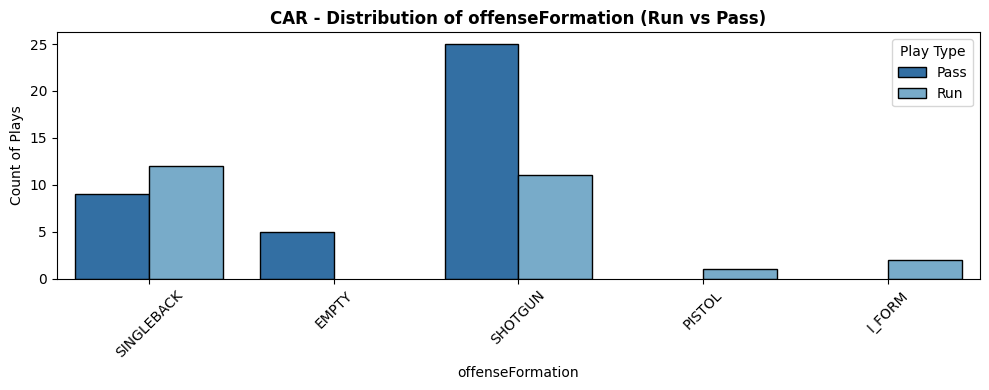

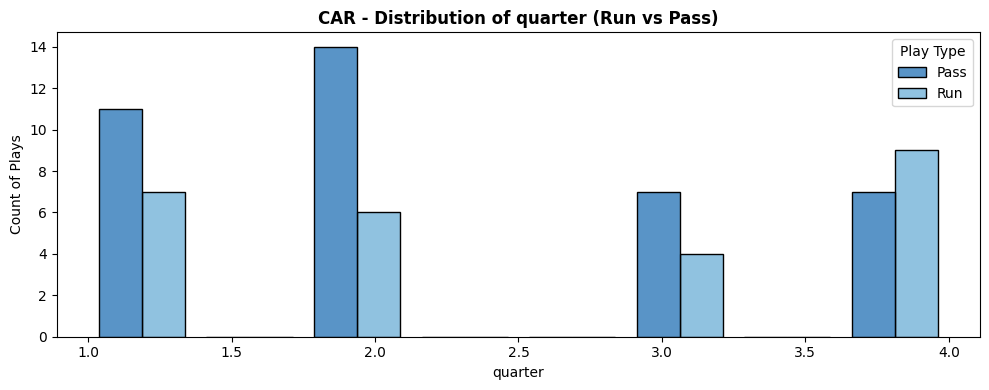

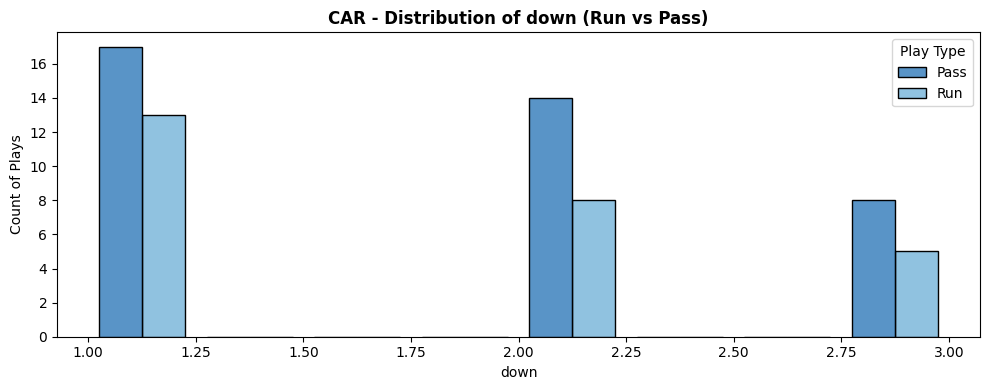

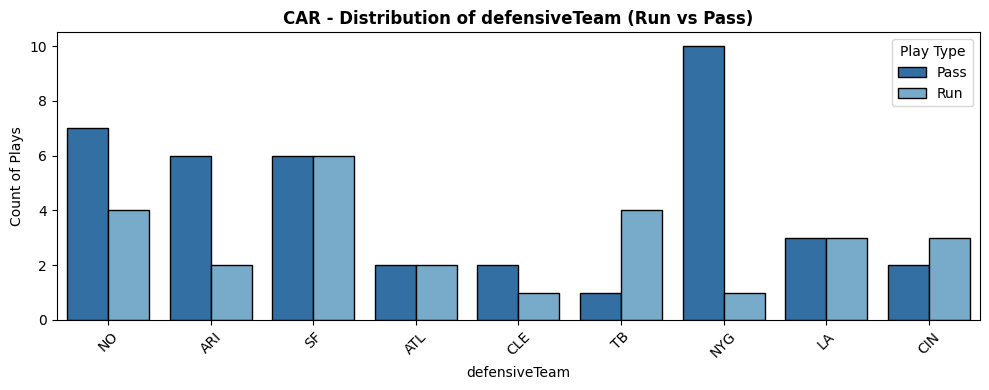

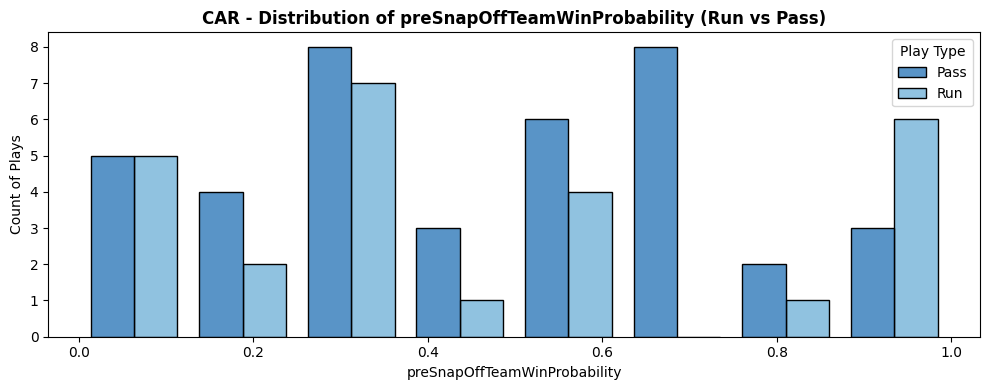

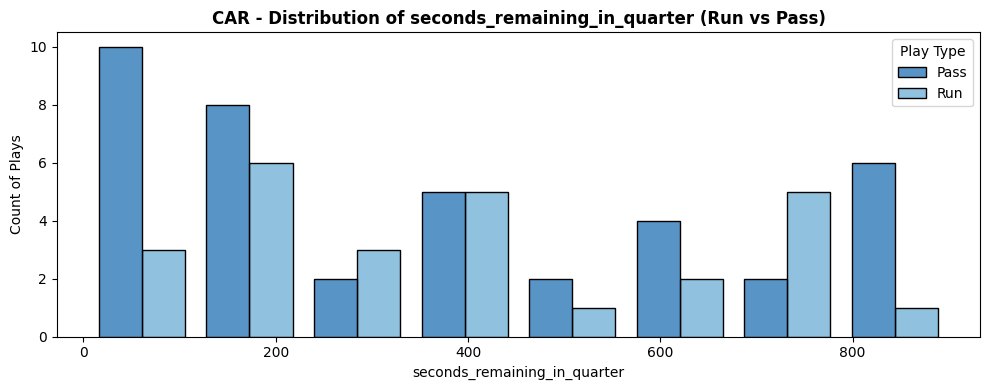

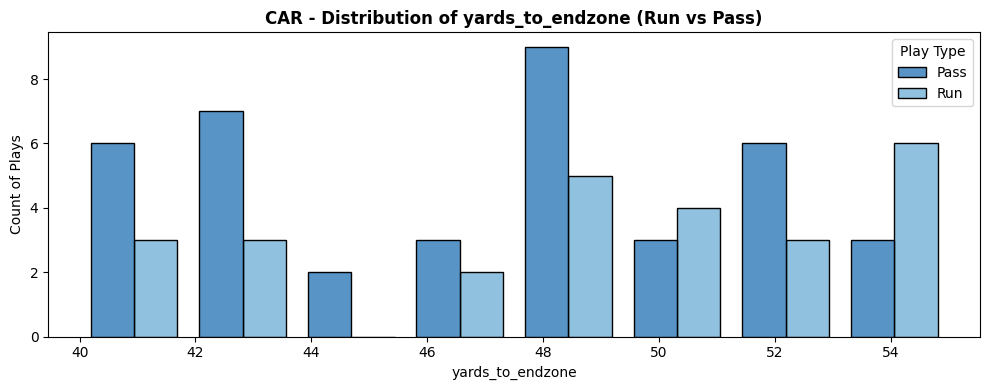

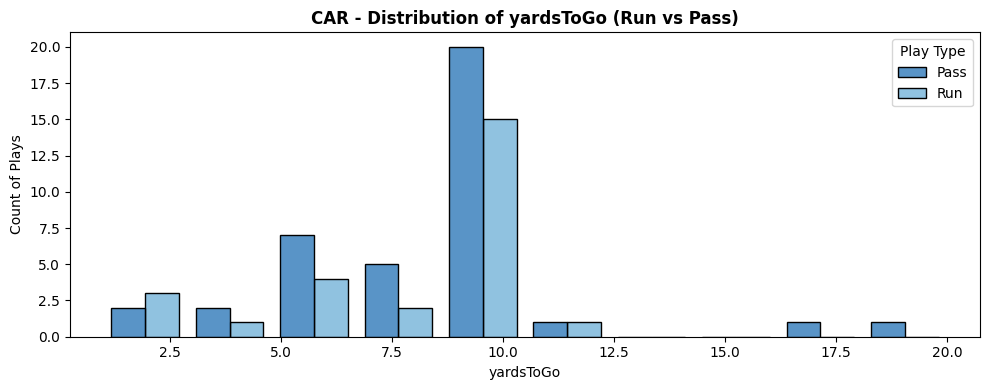

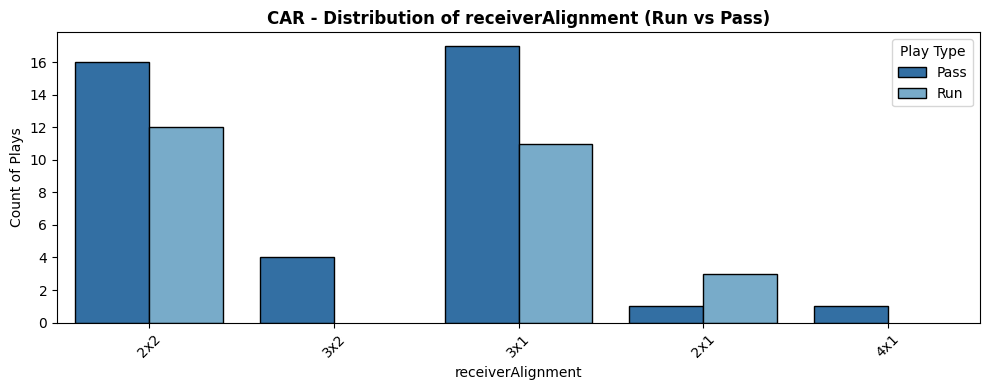

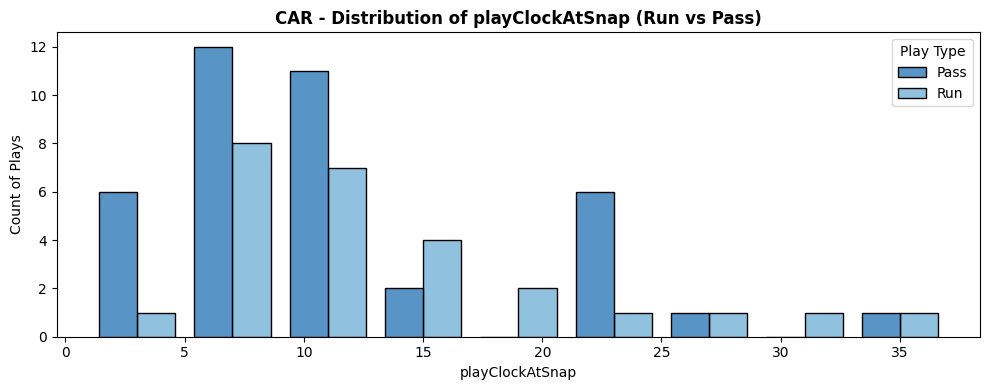

<Figure size 1000x400 with 0 Axes>

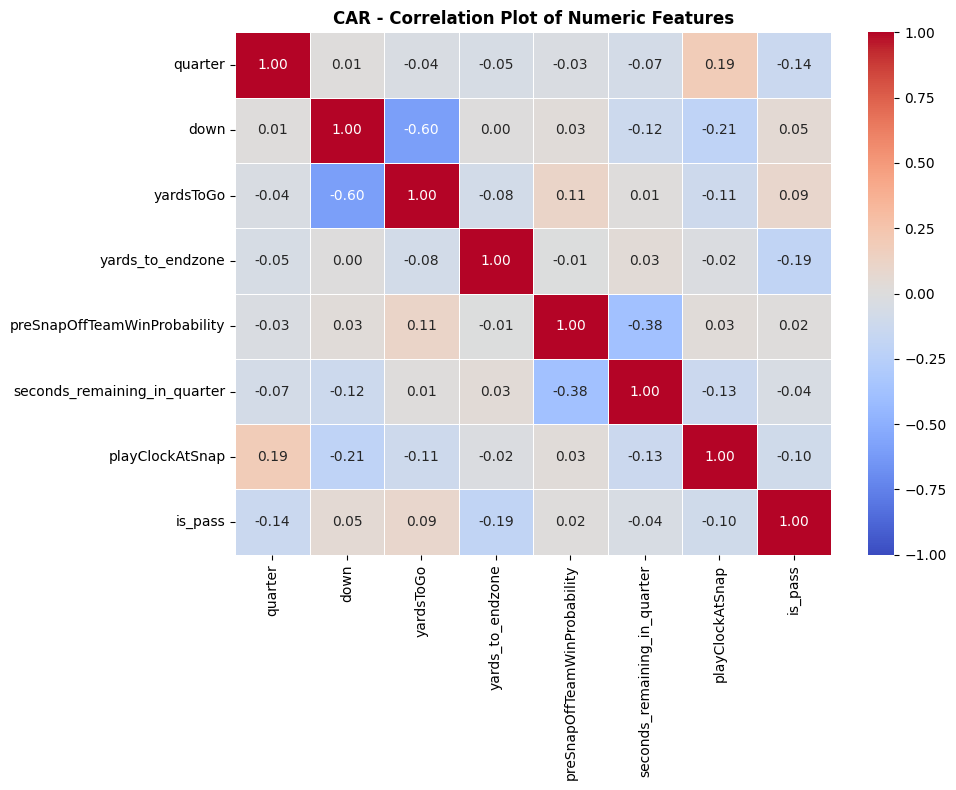

In [35]:
# Ensure max_overall_f1 is calculated
f1_cols = ['dt_f1', 'rf_f1', 'xgb_f1']
if 'max_overall_f1' not in team_performance_df.columns:
    team_performance_df['max_overall_f1'] = team_performance_df[f1_cols].max(axis=1)

# Get the row of the least predictable team
least_team_row = team_performance_df.loc[team_performance_df['max_overall_f1'].idxmin()]
least_team = least_team_row['team']
least_f1 = least_team_row['max_overall_f1']
least_model = f1_cols[team_performance_df.loc[team_performance_df['max_overall_f1'].idxmin(), f1_cols].astype(float).argmin()].split('_')[0]

# Get the row of the most predictable team to base the order on
best_team_row = team_performance_df.loc[team_performance_df['max_overall_f1'].idxmax()]
best_team = best_team_row['team']
best_model_best_team = f1_cols[team_performance_df.loc[team_performance_df['max_overall_f1'].idxmax(), f1_cols].astype(float).argmax()].split('_')[0]

print(f"Least Predictable Team: {least_team}")
print(f"Lowest Macro F1 (Best Model for this team): {least_f1:.4f} (Model: {least_model.upper()})")
print("="*60)

# Features used in prediction
categorical = ["defensiveTeam", "offenseFormation", "receiverAlignment"]
numeric = ["quarter", "down", "yardsToGo", "yards_to_endzone", "preSnapOffTeamWinProbability", "seconds_remaining_in_quarter", "playClockAtSnap"]

# Use stored Permutation Importance of the MOST predictable team to order the charts
if best_team in top_5_importances:
    imp_df = top_5_importances[best_team].copy()
    imp_df = imp_df.sort_values(by='Importance', ascending=False)

    sorted_features = imp_df['Feature'].tolist()
    importances = imp_df.set_index('Feature')['Importance'].to_dict()
else:
    print(f"[Warning] Importances not found for {best_team} in top_5_importances")
    sorted_features = categorical + numeric
    importances = {f: 0 for f in sorted_features}

# Re-create the dataframe for the LEAST predictable team
team_plays_df = team_filter(plays_df, least_team)
team_fringe_df = get_fringe_df(40, 55, team_plays_df)

# Map is_pass to string labels for the legend
team_fringe_df['Play Type'] = team_fringe_df['is_pass'].map({1: 'Pass', 0: 'Run'})

# Plot Features based on the permutation importance order of the most predictable team
for col in sorted_features:
    imp_score = importances.get(col, 0)
    plt.figure(figsize=(10, 4))

    if col in categorical:
        sns.countplot(data=team_fringe_df, x=col, hue='Play Type', palette={'Pass': '#2171b5', 'Run': '#6baed6'}, edgecolor='black')
        plt.title(f"{least_team} - Distribution of {col} (Run vs Pass)", fontweight='bold')
        plt.xlabel(col)
        plt.ylabel("Count of Plays")
        plt.xticks(rotation=45)
        plt.legend(title='Play Type')
    elif col in numeric:
        # Use histplot with multiple="dodge" and kde=False
        sns.histplot(data=team_fringe_df, x=col, hue='Play Type', multiple='dodge', shrink=0.8, palette={'Pass': '#2171b5', 'Run': '#6baed6'}, edgecolor='black', kde=False)
        plt.title(f"{least_team} - Distribution of {col} (Run vs Pass)", fontweight='bold')
        plt.xlabel(col)
        plt.ylabel("Count of Plays")

    plt.tight_layout()
    plt.show()

# Correlation plot for numeric features
plt.figure(figsize=(10, 8))
fields = numeric + ['is_pass']
corr_matrix = team_fringe_df[fields].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title(f"{least_team} - Correlation Plot of Numeric Features", fontweight='bold')
plt.tight_layout()
plt.show()


In the case of the Carolina Panthers, the explanatory variables used here are all less correlated with the response variable than the Chicago Bears. We also see differences in the distributions themselves, however, we believe that patterns would be more prominent and clear given more data.

# Conclusion

We have demonstrated that this is a strong framework for answering the two questions of (1) are some teams more predictable than others? and (2) what is predictable of those teams. Given more data this framework would show higher performance across models while maintaining interpretability as well as more clear patterns visible in the team by team analysis after studying permutation importances.

# Declaration of Resources

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- None

3. AI Tools:
- Gemini: Used to do most of the coding for this project.
```